/home/shobs/anaconda3/envs/neuro/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...
<Raw | transdef_mf2pt2_rest_raw.fif, 339 x 567000 (567.0 s), ~1.44 GiB, data loaded>
Channel types: ['grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad

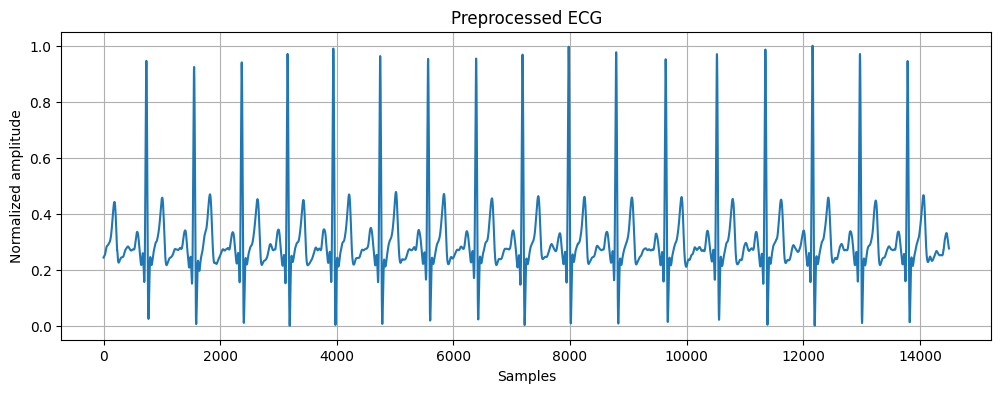

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, medfilt, decimate
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
import mne
from torchdiffeq import odeint_adjoint
import time
import sys
import gc
from scipy.signal import detrend
from scipy.integrate import solve_ivp
import torch.nn.functional as F
from tqdm.notebook import tqdm
from numpy.fft import fft, ifft
from scipy.signal import medfilt
# ===============================
# Load MEG file
# ===============================
file_new_raw = "/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif"
raw = mne.io.read_raw_fif(file_new_raw, preload=True)

print(raw)
print("Channel types:", raw.get_channel_types())


ecg_channel_index = 322
data, times = raw[ecg_channel_index, 500:15000]

ecg = -data[0]  # invert if required
sfreq = raw.info["sfreq"]

print("ECG length:", ecg.shape)
print("Sampling frequency:", sfreq)

# ===============================
# Step 1 — Detrend
# ===============================
ecg = detrend(ecg, type="linear")

# ===============================
# Step 2 — Bandpass Filter
# ===============================
lowcut = 1
highcut = 20
order = 4

b, a = butter(order, [lowcut/(0.5*sfreq), highcut/(0.5*sfreq)], btype="band")
ecg = filtfilt(b, a, ecg)

# ===============================
# Step 3 — Baseline Correction
# ===============================
def get_median_filter_width(fs, duration):
    width = int(fs * duration)
    width += ((width % 2) - 1)  # ensure odd
    return width

mfa = [get_median_filter_width(sfreq, d) for d in [0.2, 0.6]]

baseline = ecg.copy()
for w in mfa:
    baseline = medfilt(baseline, w)

ecg = ecg - baseline

# ===============================
# Step 4 — Normalization
# ===============================
ecg = (ecg - np.min(ecg)) / (np.max(ecg) - np.min(ecg))


# ===============================
# Plot
# ===============================
plt.figure(figsize=(12,4))
plt.plot(ecg)
plt.title("Preprocessed ECG")
plt.xlabel("Samples")
plt.ylabel("Normalized amplitude")
plt.grid(True)
plt.show()


--- Using device: cuda ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.015472
Epoch 2000/60000, Loss: 0.015451
Epoch 3000/60000, Loss: 0.015352
Epoch 4000/60000, Loss: 0.014898
Epoch 5000/60000, Loss: 0.014792
Epoch 6000/60000, Loss: 0.014763
Epoch 7000/60000, Loss: 0.014736
Epoch 8000/60000, Loss: 0.014702
Epoch 9000/60000, Loss: 0.014657
Epoch 10000/60000, Loss: 0.014592
Epoch 11000/60000, Loss: 0.014496
Epoch 12000/60000, Loss: 0.014356
Epoch 13000/60000, Loss: 0.014159
Epoch 14000/60000, Loss: 0.013900
Epoch 15000/60000, Loss: 0.013602
Epoch 16000/60000, Loss: 0.013303
Epoch 17000/60000, Loss: 0.013021
Epoch 18000/60000, Loss: 0.012738
Epoch 19000/60000, Loss: 0.012437
Epoch 20000/60000, Loss: 0.012121
Epoch 21000/60000, Loss: 0.011806
Epoch 22000/60000, Loss: 0.011936
Epoch 23000/60000, Loss: 0.011275
Epoch 24000/60000, Loss: 0.011084
Epoch 25000/60000, Loss: 0.010932
Epoch 26000/60000, Loss: 0.010787
Epoch 27000/60000, Loss: 0.010636
Epoch 28000/60000, Loss: 

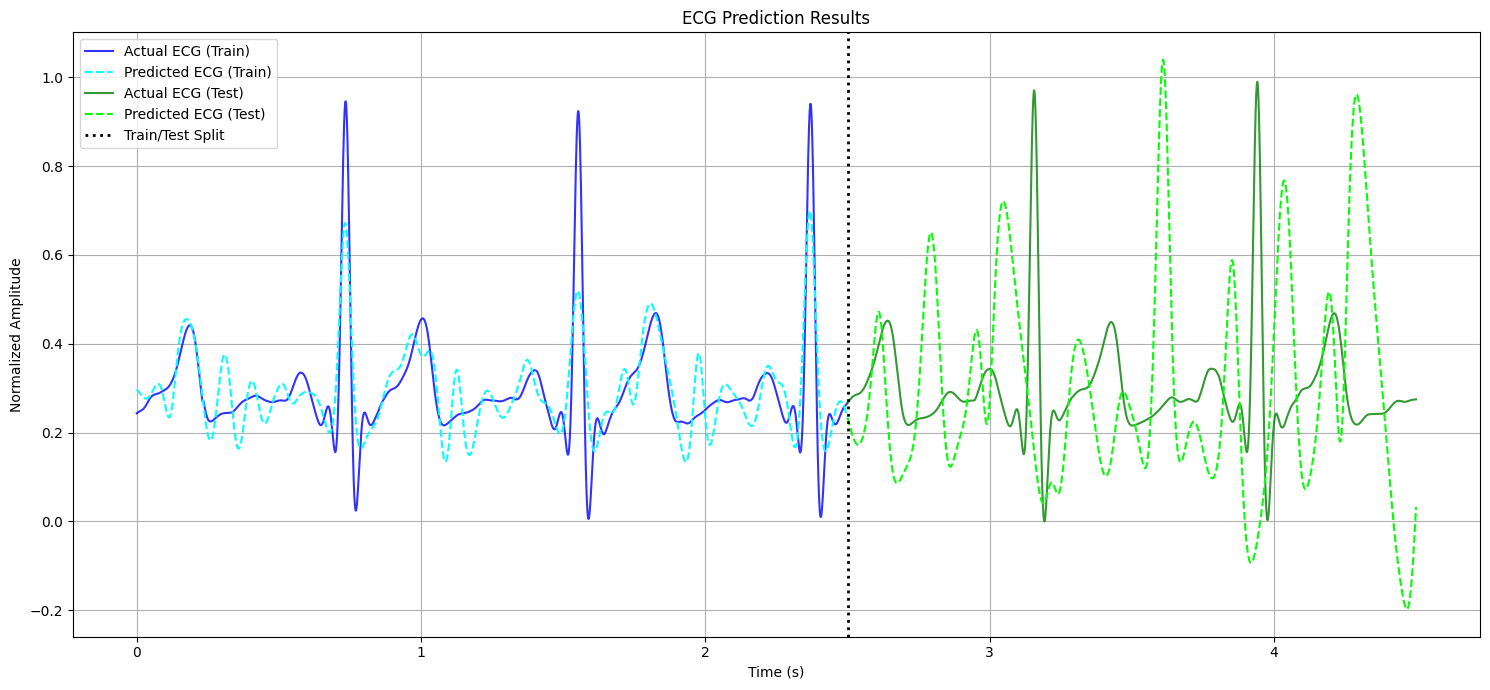

In [2]:
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = ecg

    # Time vectors for plotting
    train_duration= 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)
    # Slice ecg_processed to total_duration first:
    total_samples = int(total_duration * fs)   # = 4500
    ecg_processed = ecg_processed[:total_samples]   # cap at 4.5s

    # Then split:
    train_samples  = int(train_duration * fs)  # = 2500
    ecg_train = ecg_processed[:train_samples]  # 2500 samples
    ecg_test  = ecg_processed[train_samples:]  # 2000 samples ✓

    # Verify before plotting:
    assert len(t_train) == len(ecg_train), f"{len(t_train)} vs {len(ecg_train)}"
    assert len(t_test)  == len(ecg_test),  f"{len(t_test)} vs {len(ecg_test)}"

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Next Try

--- Using device: cuda ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.014927
Epoch 2000/60000, Loss: 0.014867
Epoch 3000/60000, Loss: 0.014815
Epoch 4000/60000, Loss: 0.014744
Epoch 5000/60000, Loss: 0.014654
Epoch 6000/60000, Loss: 0.014429
Epoch 7000/60000, Loss: 0.014003
Epoch 8000/60000, Loss: 0.013410
Epoch 9000/60000, Loss: 0.012916
Epoch 10000/60000, Loss: 0.012470
Epoch 11000/60000, Loss: 0.012441
Epoch 12000/60000, Loss: 0.012149
Epoch 13000/60000, Loss: 0.012079
Epoch 14000/60000, Loss: 0.011996
Epoch 15000/60000, Loss: 0.011941
Epoch 16000/60000, Loss: 0.011914
Epoch 17000/60000, Loss: 0.011812
Epoch 18000/60000, Loss: 0.011725
Epoch 19000/60000, Loss: 0.011616
Epoch 20000/60000, Loss: 0.011481
Epoch 21000/60000, Loss: 0.011339
Epoch 22000/60000, Loss: 0.011197
Epoch 23000/60000, Loss: 0.011152
Epoch 24000/60000, Loss: 0.010922
Epoch 25000/60000, Loss: 0.010842
Epoch 26000/60000, Loss: 0.010710
Epoch 27000/60000, Loss: 0.010644
Epoch 28000/60000, Loss: 

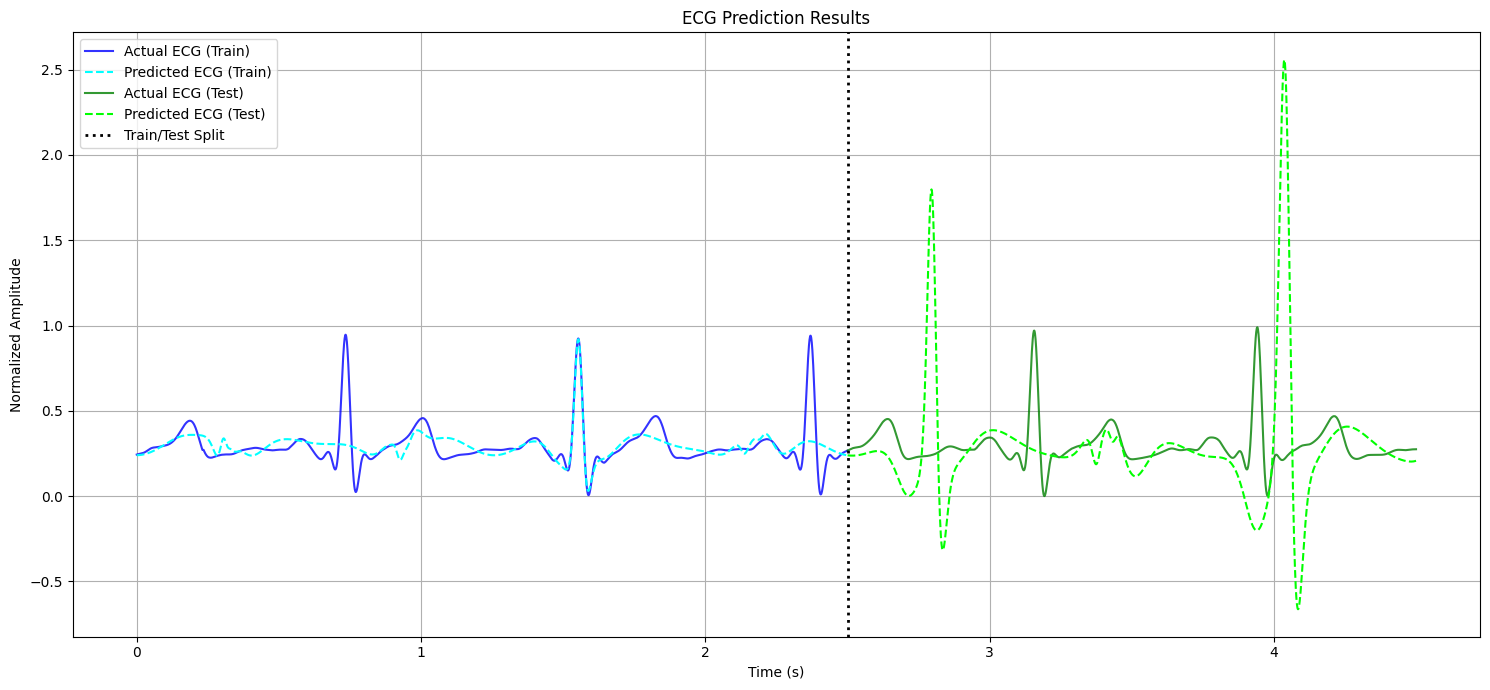

In [4]:
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R2 * np.cos(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=2, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = ecg

    # Time vectors for plotting
    train_duration= 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    total_samples=len(t_full)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:total_samples].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--- Using device: cpu ---

--- Starting Heart Model Training (with regularization) ---
Epoch 1000/120000, Loss: 0.011790
Epoch 2000/120000, Loss: 0.011562
Epoch 3000/120000, Loss: 0.011332
Epoch 4000/120000, Loss: 0.011110
Epoch 5000/120000, Loss: 0.010943
Epoch 6000/120000, Loss: 0.010596
Epoch 7000/120000, Loss: 0.010446
Epoch 8000/120000, Loss: 0.010205
Epoch 9000/120000, Loss: 0.009898
Epoch 10000/120000, Loss: 0.009829
Epoch 11000/120000, Loss: 0.009705
Epoch 12000/120000, Loss: 0.009734
Epoch 13000/120000, Loss: 0.009386
Epoch 14000/120000, Loss: 0.009203
Epoch 15000/120000, Loss: 0.009245
Epoch 16000/120000, Loss: 0.009003
Epoch 17000/120000, Loss: 0.008822
Epoch 18000/120000, Loss: 0.008853
Epoch 19000/120000, Loss: 0.008881
Epoch 20000/120000, Loss: 0.008813
Epoch 21000/120000, Loss: 0.008548
Epoch 22000/120000, Loss: 0.008260
Epoch 23000/120000, Loss: 0.008196
Epoch 24000/120000, Loss: 0.007767
Epoch 25000/120000, Loss: 0.008096
Epoch 26000/120000, Loss: 0.008048
Epoch 27000/

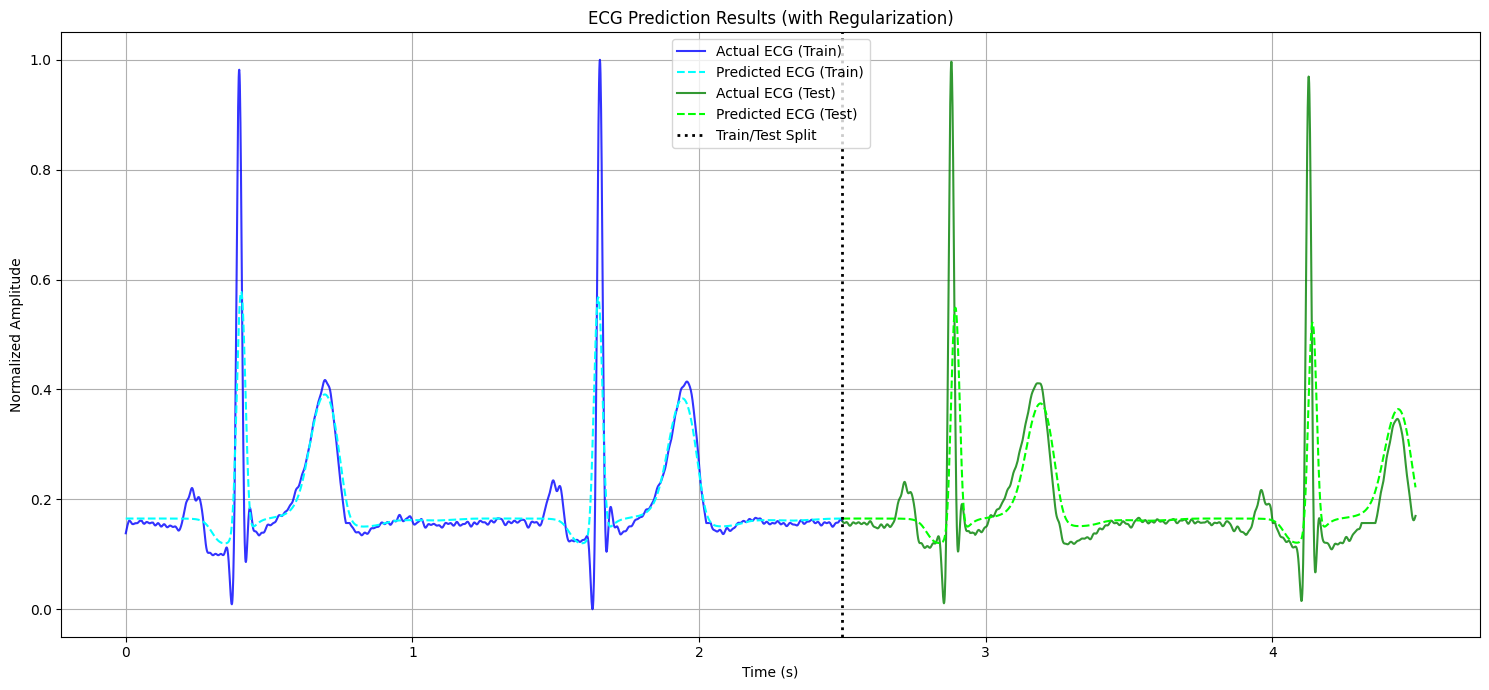

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Coupling
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Dynamics
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# -------------------
# Heart model with regularization
# -------------------
class HeartModel(nn.Module):
    """Map oscillator states (4) to ECG (1) with dropout regularization."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(p_drop),   # dropout after activation
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

def l1_penalty(model):
    return sum(p.abs().sum() for p in model.parameters())


if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    # Expect normalized_ecg_basecorrect to be defined externally as a 1D numpy array
    ecg_processed = normalized_ecg_basecorrect

    # Time vectors
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # 3. Initialize model, optimizer, and loss
    heart_model = HeartModel(p_drop=0.2).to(device)  # dropout enabled only in training
    criterion = nn.MSELoss()

    # AdamW with decoupled weight decay
    optimizer = optim.AdamW(heart_model.parameters(), lr=1e-4, weight_decay=1e-4)  # tune wd 1e-5..3e-4 [web:36][web:33]

    # Optional L1 penalty coefficient (0 disables)
    l1_lambda = 1e-6  # set e.g., 1e-6 to enable small L1 [web:21][web:31]

    # 4. Prepare training data
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32, device=device
    )
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32, device=device).unsqueeze(1)

    # 5. Training loop with gradient clipping
    print("\n--- Starting Heart Model Training (with regularization) ---")
    num_epochs = 120000
    for epoch in range(num_epochs):
        heart_model.train()

        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Optional L1
        if l1_lambda > 0:
            loss = loss + l1_lambda * l1_penalty(heart_model)

        optimizer.zero_grad()
        loss.backward()

        # Clip grad norm to stabilize [web:45][web:52]
        #nn.utils.clip_grad_norm_(heart_model.parameters(), max_norm=2.0)

        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32, device=device
        )
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with Regularization)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Code test..

--- Using device: cuda ---

--- Starting Heart Model Training (with regularization) ---
Epoch 1000/40000, Loss: 0.018691
Epoch 2000/40000, Loss: 0.016848
Epoch 3000/40000, Loss: 0.016455
Epoch 4000/40000, Loss: 0.016572
Epoch 5000/40000, Loss: 0.016241
Epoch 6000/40000, Loss: 0.016219
Epoch 7000/40000, Loss: 0.016034
Epoch 8000/40000, Loss: 0.016000
Epoch 9000/40000, Loss: 0.015871
Epoch 10000/40000, Loss: 0.015834
Epoch 11000/40000, Loss: 0.015724
Epoch 12000/40000, Loss: 0.015724
Epoch 13000/40000, Loss: 0.015673
Epoch 14000/40000, Loss: 0.015688
Epoch 15000/40000, Loss: 0.015703
Epoch 16000/40000, Loss: 0.015655
Epoch 17000/40000, Loss: 0.015648
Epoch 18000/40000, Loss: 0.015686
Epoch 19000/40000, Loss: 0.015637
Epoch 20000/40000, Loss: 0.015612
Epoch 21000/40000, Loss: 0.015646
Epoch 22000/40000, Loss: 0.015605
Epoch 23000/40000, Loss: 0.015603
Epoch 24000/40000, Loss: 0.015624
Epoch 25000/40000, Loss: 0.015616
Epoch 26000/40000, Loss: 0.015616
Epoch 27000/40000, Loss: 0.015551
Epo

ValueError: x and y must have same first dimension, but have shapes (2000,) and (12000,)

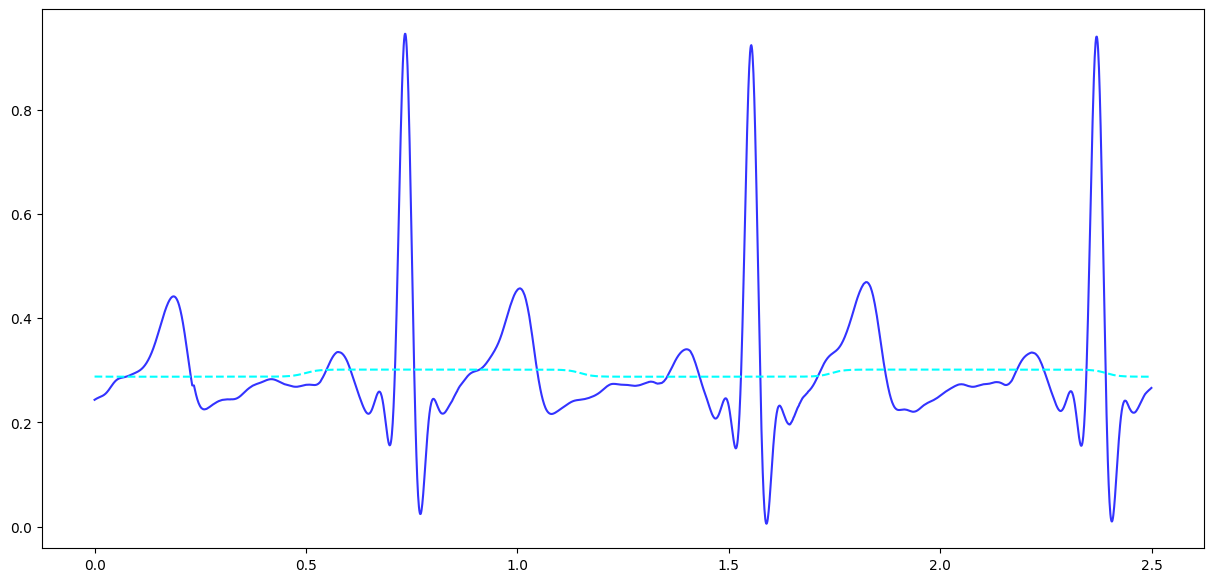

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------
# Oscillator simulator (unchanged numerics)
# -------------------
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=2.0, omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Coupling
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Dynamics
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# -------------------
# Heart model with regularization
# -------------------
class HeartModel(nn.Module):
    """Map oscillator states (4) to ECG (1) with dropout regularization."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(p_drop),   # dropout after activation
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

def l1_penalty(model):
    return sum(p.abs().sum() for p in model.parameters())

# -------------------
# Main
# -------------------
if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    # Expect normalized_ecg_basecorrect to be defined externally as a 1D numpy array
    ecg_processed = ecg

    # Time vectors
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # 3. Initialize model, optimizer, and loss
    heart_model = HeartModel(p_drop=0.2).to(device)  # dropout enabled only in training
    criterion = nn.MSELoss()

    # AdamW with decoupled weight decay
    optimizer = optim.AdamW(heart_model.parameters(), lr=1e-4, weight_decay=1e-4)  # tune wd 1e-5..3e-4 [web:36][web:33]

    # Optional L1 penalty coefficient (0 disables)
    l1_lambda = 1e-6  # set e.g., 1e-6 to enable small L1 [web:21][web:31]

    # 4. Prepare training data
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32, device=device
    )
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32, device=device).unsqueeze(1)

    # 5. Training loop with gradient clipping
    print("\n--- Starting Heart Model Training (with regularization) ---")
    num_epochs = 40000
    for epoch in range(num_epochs):
        heart_model.train()

        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Optional L1
        if l1_lambda > 0:
            loss = loss + l1_lambda * l1_penalty(heart_model)

        optimizer.zero_grad()
        loss.backward()

        # Clip grad norm to stabilize [web:45][web:52]
        #nn.utils.clip_grad_norm_(heart_model.parameters(), max_norm=2.0)

        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32, device=device
        )
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with Regularization)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Do..

--- Using device: cuda ---

--- Starting Heart Model Training ---
Epoch 1000/20000, Loss: 0.012314
Epoch 2000/20000, Loss: 0.012293
Epoch 3000/20000, Loss: 0.012197
Epoch 4000/20000, Loss: 0.011905
Epoch 5000/20000, Loss: 0.011868
Epoch 6000/20000, Loss: 0.011851
Epoch 7000/20000, Loss: 0.011838
Epoch 8000/20000, Loss: 0.011823
Epoch 9000/20000, Loss: 0.011802
Epoch 10000/20000, Loss: 0.011774
Epoch 11000/20000, Loss: 0.011733
Epoch 12000/20000, Loss: 0.011674
Epoch 13000/20000, Loss: 0.011588
Epoch 14000/20000, Loss: 0.011465
Epoch 15000/20000, Loss: 0.011307
Epoch 16000/20000, Loss: 0.011134
Epoch 17000/20000, Loss: 0.010982
Epoch 18000/20000, Loss: 0.010848
Epoch 19000/20000, Loss: 0.010719
Epoch 20000/20000, Loss: 0.010576
--- Heart Model Training Finished ---

--- Generating Final Predictions ---


ValueError: x and y must have same first dimension, but have shapes (2000,) and (12000,)

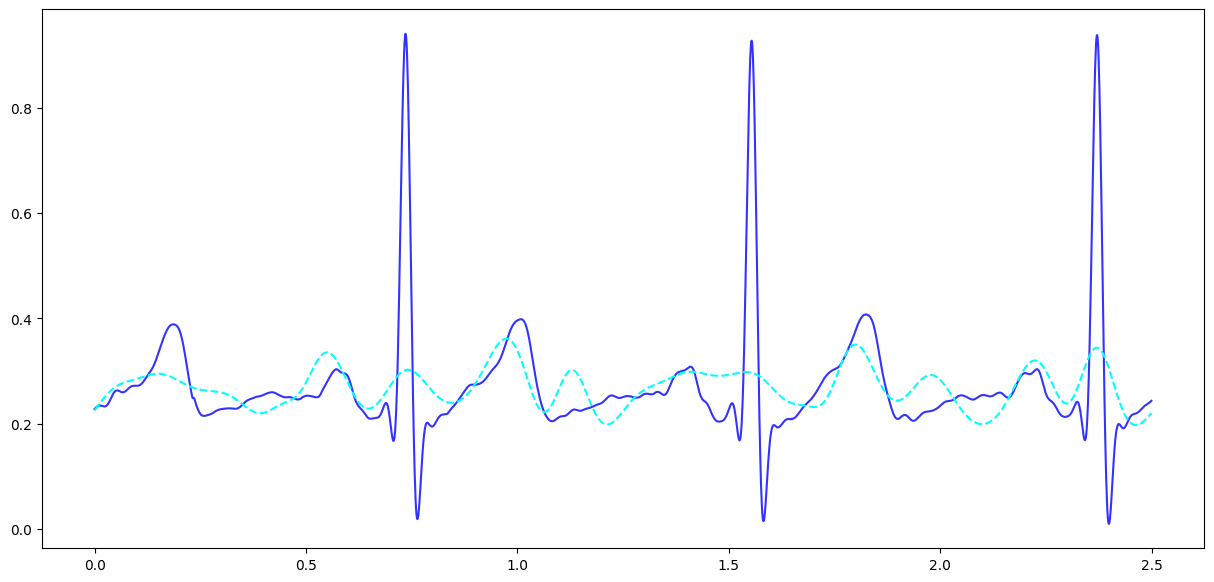

In [17]:
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = normalized_ecg_basecorrect

    # Time vectors for plotting
    train_duration= 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 20000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Lets test with other base correction formulation and denoising..

--- Using device: cuda ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.012319
Epoch 2000/60000, Loss: 0.012311
Epoch 3000/60000, Loss: 0.012285
Epoch 4000/60000, Loss: 0.012182
Epoch 5000/60000, Loss: 0.011909
Epoch 6000/60000, Loss: 0.011863
Epoch 7000/60000, Loss: 0.011840
Epoch 8000/60000, Loss: 0.011828
Epoch 9000/60000, Loss: 0.011798
Epoch 10000/60000, Loss: 0.011769
Epoch 11000/60000, Loss: 0.011728
Epoch 12000/60000, Loss: 0.011663
Epoch 13000/60000, Loss: 0.011562
Epoch 14000/60000, Loss: 0.011420
Epoch 15000/60000, Loss: 0.011247
Epoch 16000/60000, Loss: 0.011075
Epoch 17000/60000, Loss: 0.010923
Epoch 18000/60000, Loss: 0.010777
Epoch 19000/60000, Loss: 0.010614
Epoch 20000/60000, Loss: 0.010424
Epoch 21000/60000, Loss: 0.010209
Epoch 22000/60000, Loss: 0.009988
Epoch 23000/60000, Loss: 0.009784
Epoch 24000/60000, Loss: 0.009642
Epoch 25000/60000, Loss: 0.009490
Epoch 26000/60000, Loss: 0.009389
Epoch 27000/60000, Loss: 0.009301
Epoch 28000/60000, Loss: 

ValueError: x and y must have same first dimension, but have shapes (2000,) and (12000,)

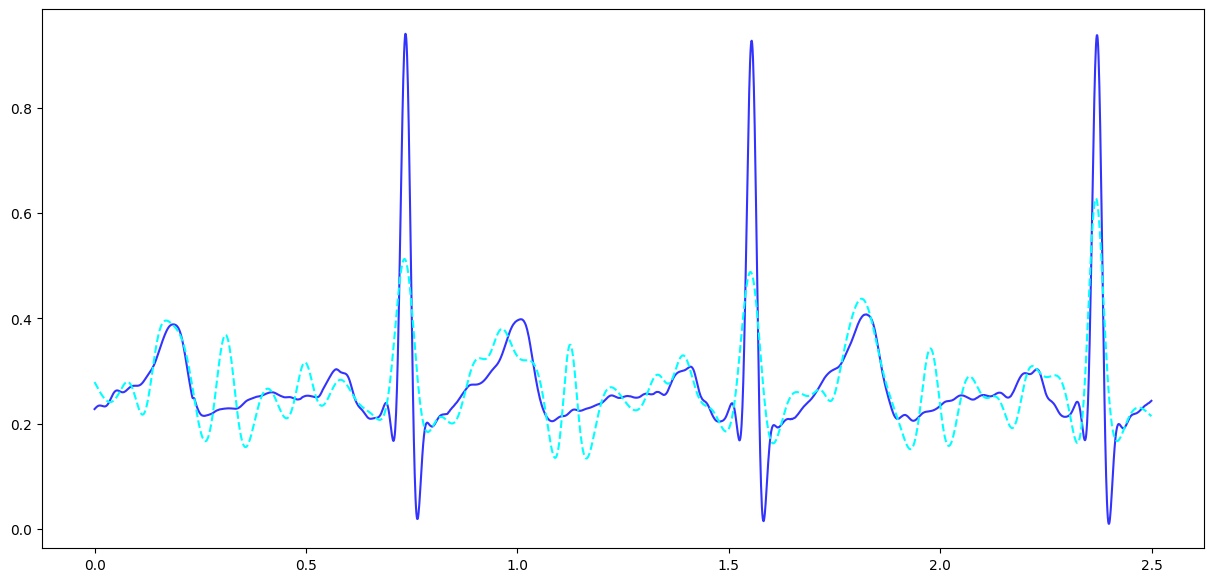

In [18]:
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi/2, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = normalized_ecg_basecorrect

    # Time vectors for plotting
    train_duration= 2.5
    total_duration = 4.5
    fs = 1000
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.010849, Val=0.000180
Epoch 1000, Train=0.006256, Val=0.000242
Epoch 1500, Train=0.003702, Val=0.000236
Epoch 2000, Train=0.002901, Val=0.000180
Epoch 2500, Train=0.002005, Val=0.000155
Epoch 3000, Train=0.001226, Val=0.000116
Epoch 3500, Train=0.001010, Val=0.000053
Epoch 4000, Train=0.000765, Val=0.000041
Epoch 4500, Train=0.000633, Val=0.000038
Epoch 5000, Train=0.000482, Val=0.000019
Epoch 5500, Train=0.000479, Val=0.000018
Epoch 6000, Train=0.000422, Val=0.000018
Epoch 6500, Train=0.000343, Val=0.000012
Epoch 7000, Train=0.000385, Val=0.000020
Epoch 7500, Train=0.000342, Val=0.000013
Epoch 8000, Train=0.000385, Val=0.000012
--- Training Finished ---



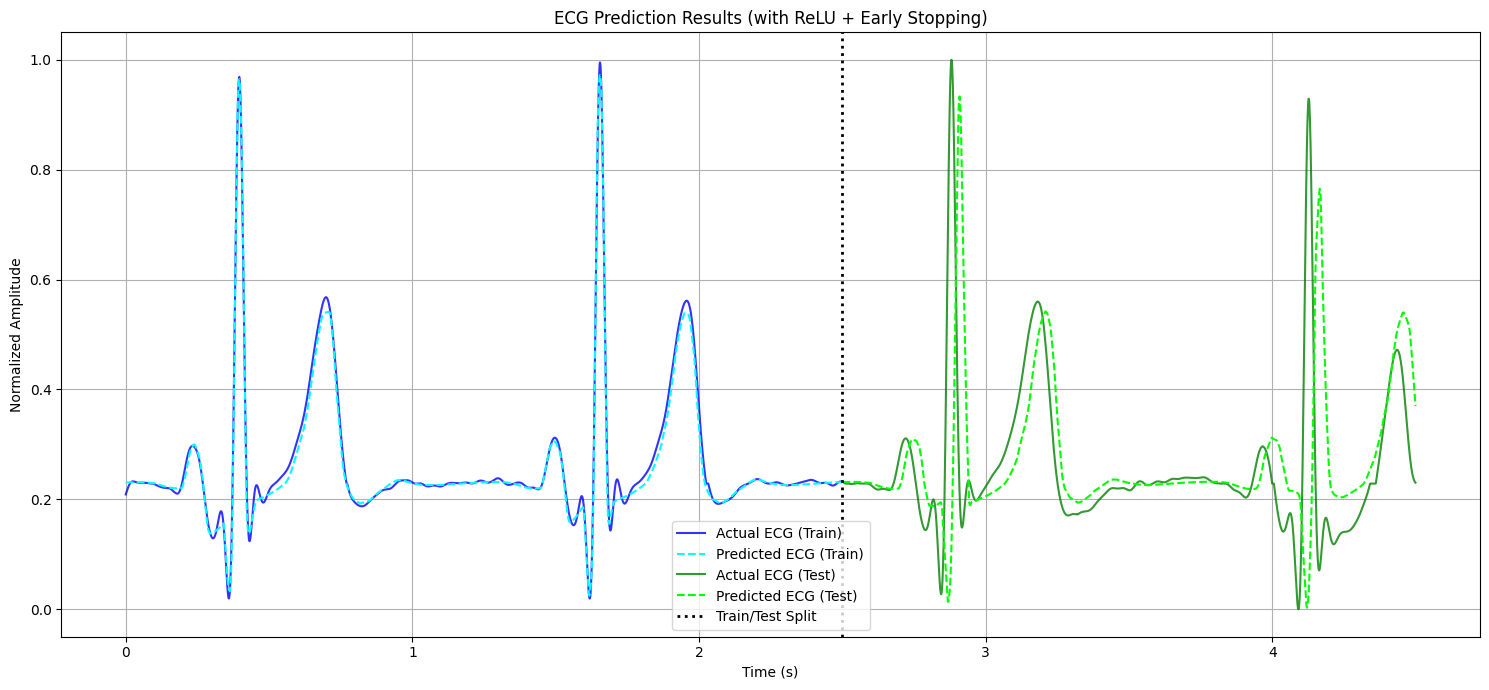

In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=np.pi/2, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1),
                     R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 8000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.008271, Val=0.000056
Early stopping triggered.
--- Training Finished ---



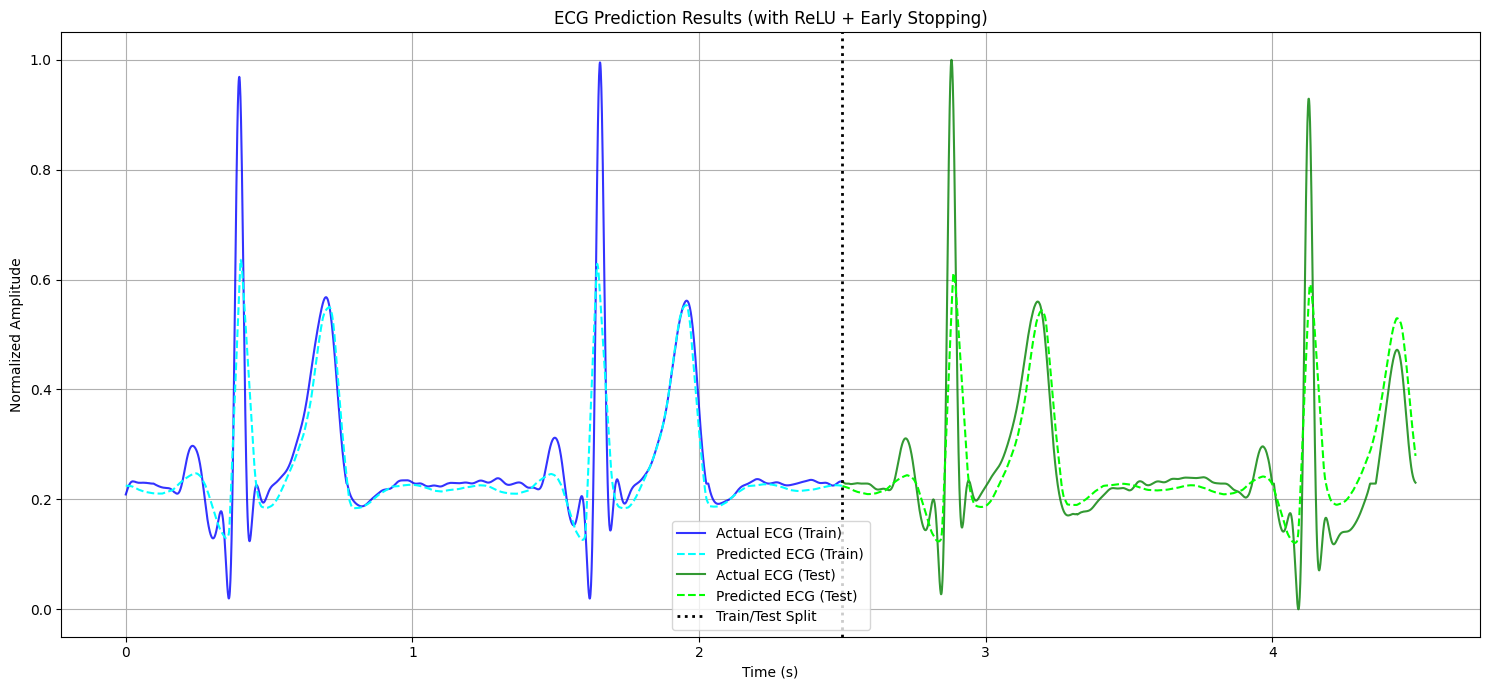

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1),
                     R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 5000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

        if wait > patience:
            print("Early stopping triggered.")
            break

    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## dance

--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.007569, Val=0.000455
Epoch 1000, Train=0.004275, Val=0.000338
Epoch 1500, Train=0.002784, Val=0.000313
Epoch 2000, Train=0.002492, Val=0.000315
Epoch 2500, Train=0.002179, Val=0.000340
Epoch 3000, Train=0.002308, Val=0.000388
Epoch 3500, Train=0.002083, Val=0.000389
Epoch 4000, Train=0.002099, Val=0.000384
Epoch 4500, Train=0.001901, Val=0.000372
Epoch 5000, Train=0.001954, Val=0.000349
Epoch 5500, Train=0.001764, Val=0.000327
Epoch 6000, Train=0.001544, Val=0.000301
Epoch 6500, Train=0.001577, Val=0.000285
Epoch 7000, Train=0.001174, Val=0.000264
Epoch 7500, Train=0.001021, Val=0.000245
Epoch 8000, Train=0.000899, Val=0.000237
Epoch 8500, Train=0.000849, Val=0.000227
Epoch 9000, Train=0.000800, Val=0.000239
Epoch 9500, Train=0.000608, Val=0.000233
Epoch 10000, Train=0.000665, Val=0.000230
Epoch 10500, Train=0.000554, Val=0.000219
Epoch 11000, Train=0.000484, Val=0.000218
Epoch 11500, Train=0.000443, Val=0.000212
E

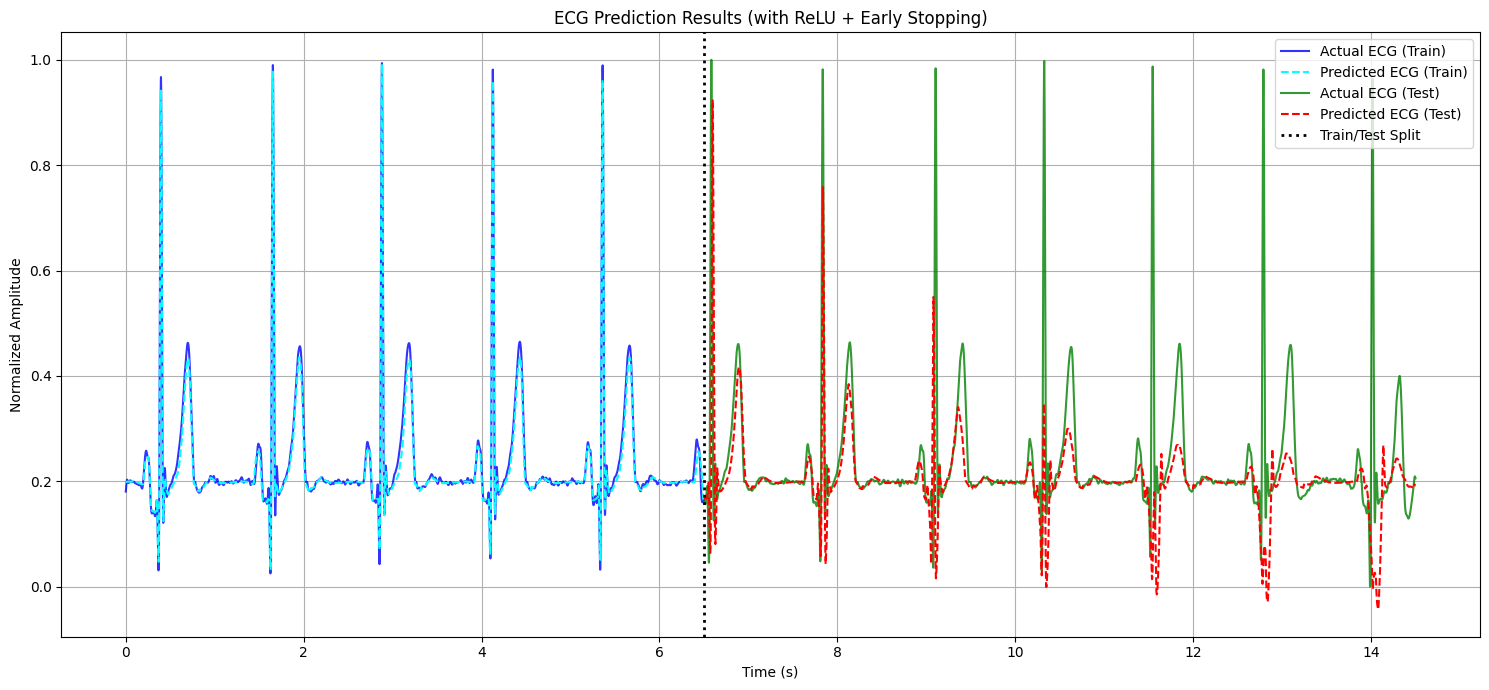

In [53]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=15, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.08,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1),
                     R2*np.sin(Phi2),
                     R2*np.cos(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 6.5
    total_duration = 14.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 18000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='red', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.014564, Val=0.000128
Epoch 1000, Train=0.008668, Val=0.000205
Epoch 1500, Train=0.005552, Val=0.000328
Epoch 2000, Train=0.003710, Val=0.000212
Epoch 2500, Train=0.002850, Val=0.000063
Epoch 3000, Train=0.002280, Val=0.000046
Epoch 3500, Train=0.001811, Val=0.000028
Epoch 4000, Train=0.001322, Val=0.000017
Epoch 4500, Train=0.001397, Val=0.000022
Epoch 5000, Train=0.001179, Val=0.000020
Epoch 5500, Train=0.000900, Val=0.000025
Epoch 6000, Train=0.000951, Val=0.000022
Epoch 6500, Train=0.000671, Val=0.000015
Epoch 7000, Train=0.000705, Val=0.000020
Epoch 7500, Train=0.000711, Val=0.000018
Epoch 8000, Train=0.000535, Val=0.000016
--- Training Finished ---



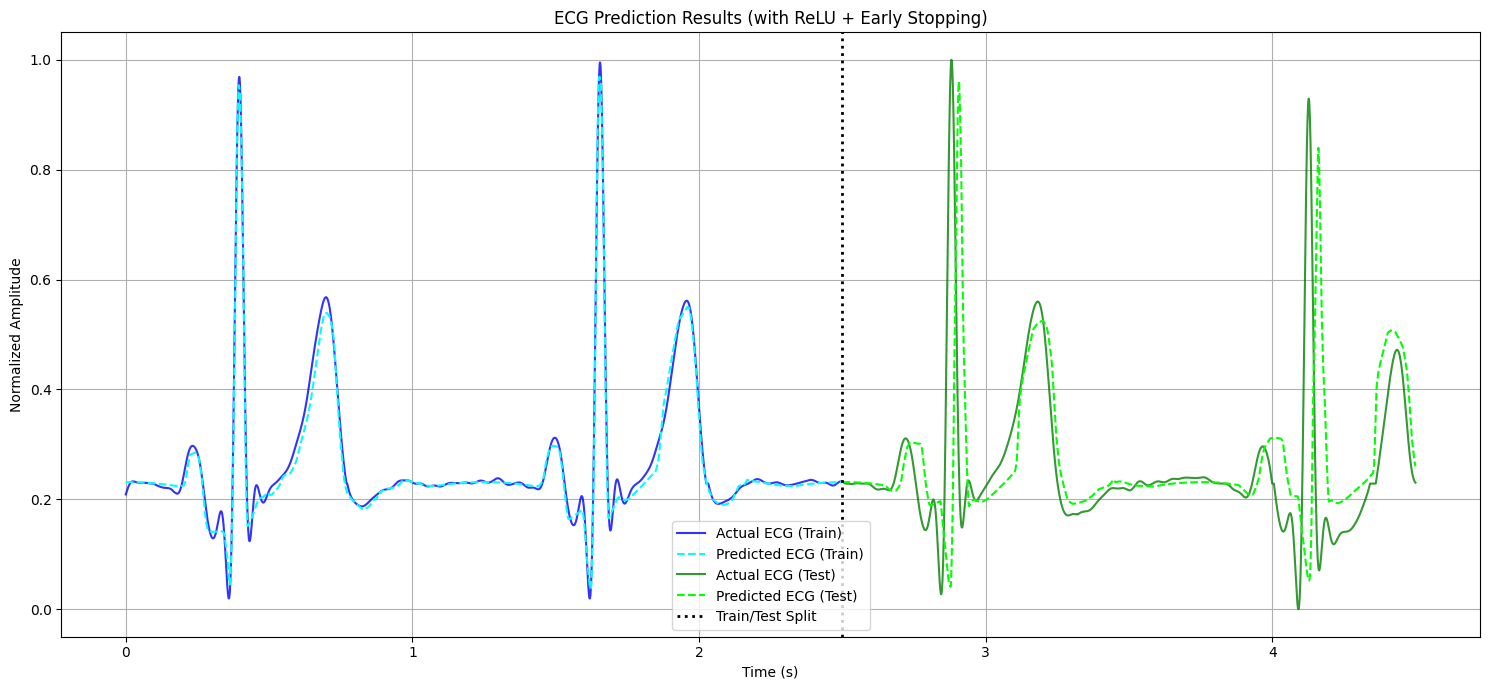

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=15, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.08,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),
                     R2*np.cos(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 6.5
    total_duration = 14.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 8000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.014564, Val=0.000128
Epoch 1000, Train=0.008668, Val=0.000205
Epoch 1500, Train=0.005552, Val=0.000328
Epoch 2000, Train=0.003710, Val=0.000212
Epoch 2500, Train=0.002850, Val=0.000063
Epoch 3000, Train=0.002280, Val=0.000046
Epoch 3500, Train=0.001811, Val=0.000028
Epoch 4000, Train=0.001322, Val=0.000017
Epoch 4500, Train=0.001397, Val=0.000022
Epoch 5000, Train=0.001179, Val=0.000020
Epoch 5500, Train=0.000900, Val=0.000025
Epoch 6000, Train=0.000951, Val=0.000022
Epoch 6500, Train=0.000671, Val=0.000015
Epoch 7000, Train=0.000705, Val=0.000020
Epoch 7500, Train=0.000711, Val=0.000018
Epoch 8000, Train=0.000535, Val=0.000016
--- Training Finished ---



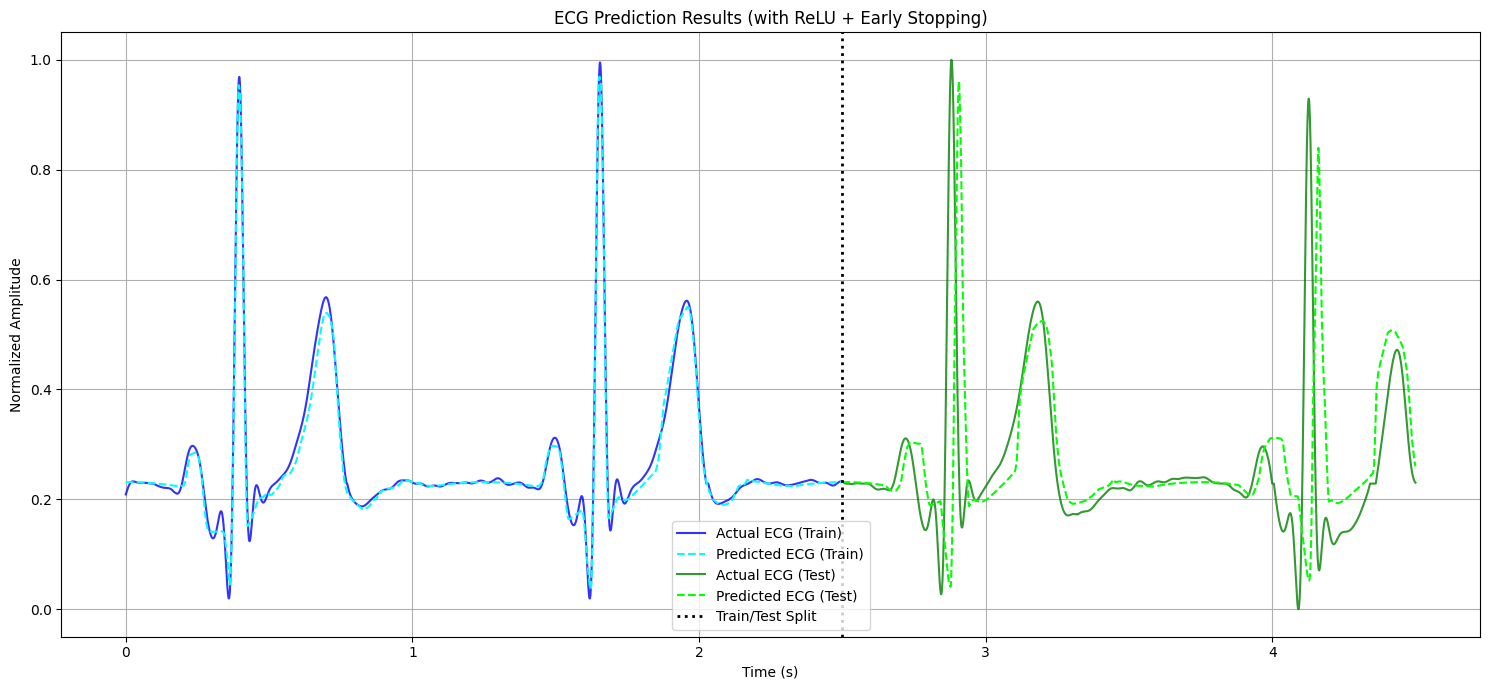

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0, omega1=5.01, omega2=5.08,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),
                     R2*np.cos(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 8000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")


    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## two

--- Using device: cpu ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.005003
Epoch 2000/60000, Loss: 0.002496
Epoch 3000/60000, Loss: 0.002046
Epoch 4000/60000, Loss: 0.001893
Epoch 5000/60000, Loss: 0.001819
Epoch 6000/60000, Loss: 0.001758
Epoch 7000/60000, Loss: 0.001683
Epoch 8000/60000, Loss: 0.001583
Epoch 9000/60000, Loss: 0.001425
Epoch 10000/60000, Loss: 0.001241
Epoch 11000/60000, Loss: 0.001091
Epoch 12000/60000, Loss: 0.000966
Epoch 13000/60000, Loss: 0.000875
Epoch 14000/60000, Loss: 0.000800
Epoch 15000/60000, Loss: 0.000755
Epoch 16000/60000, Loss: 0.000721
Epoch 17000/60000, Loss: 0.000705
Epoch 18000/60000, Loss: 0.000664
Epoch 19000/60000, Loss: 0.000640
Epoch 20000/60000, Loss: 0.000622
Epoch 21000/60000, Loss: 0.000606
Epoch 22000/60000, Loss: 0.000593
Epoch 23000/60000, Loss: 0.000581
Epoch 24000/60000, Loss: 0.000675
Epoch 25000/60000, Loss: 0.000560
Epoch 26000/60000, Loss: 0.000550
Epoch 27000/60000, Loss: 0.000539
Epoch 28000/60000, Loss: 0

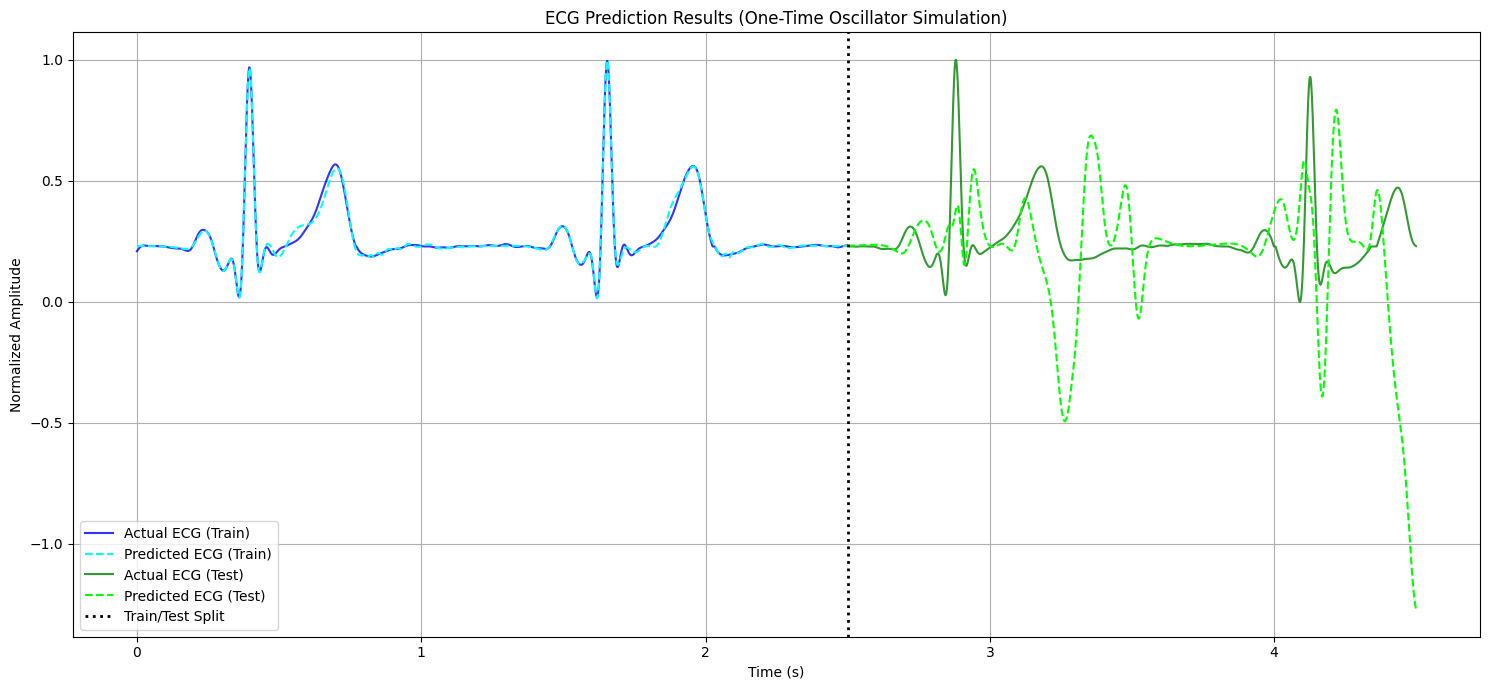

In [55]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation (NumPy) ---
def simulate_coupled_oscillators(T=5, dt=0.001, alpha=1.0,
                                 omega1=5.01, omega2=5.1,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1 * np.cos(Phi1),
                     R1*np.sin(Phi1),
                     R2 * np.cos(Phi2),
                     R2*np.sin(Phi2)
                     ), axis=1)

# --- PyTorch Heart Model ---
class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=2, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
            nn.Sigmoid(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load ECG data
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 2.5
    total_duration = 4.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX: simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np, dtype=torch.float32).to(device)
    sim_osc_input_train = sim_osc_input_full[:train_samples]

    # Training target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # 4. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 5. Evaluation on FULL signal
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # 6. Plot results
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (One-Time Oscillator Simulation)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.008500, Val=nan
Epoch 1000, Train=0.006429, Val=nan
Epoch 1500, Train=0.004576, Val=nan
Epoch 2000, Train=0.003087, Val=nan
Epoch 2500, Train=0.002951, Val=nan
Epoch 3000, Train=0.001619, Val=nan
Epoch 3500, Train=0.001623, Val=nan
Epoch 4000, Train=0.001388, Val=nan
Epoch 4500, Train=0.001321, Val=nan
Epoch 5000, Train=0.001716, Val=nan
Epoch 5500, Train=0.001089, Val=nan
Epoch 6000, Train=0.000705, Val=nan
Epoch 6500, Train=0.000625, Val=nan
Epoch 7000, Train=0.000821, Val=nan
Epoch 7500, Train=0.000625, Val=nan
Epoch 8000, Train=0.000875, Val=nan
--- Training Finished ---



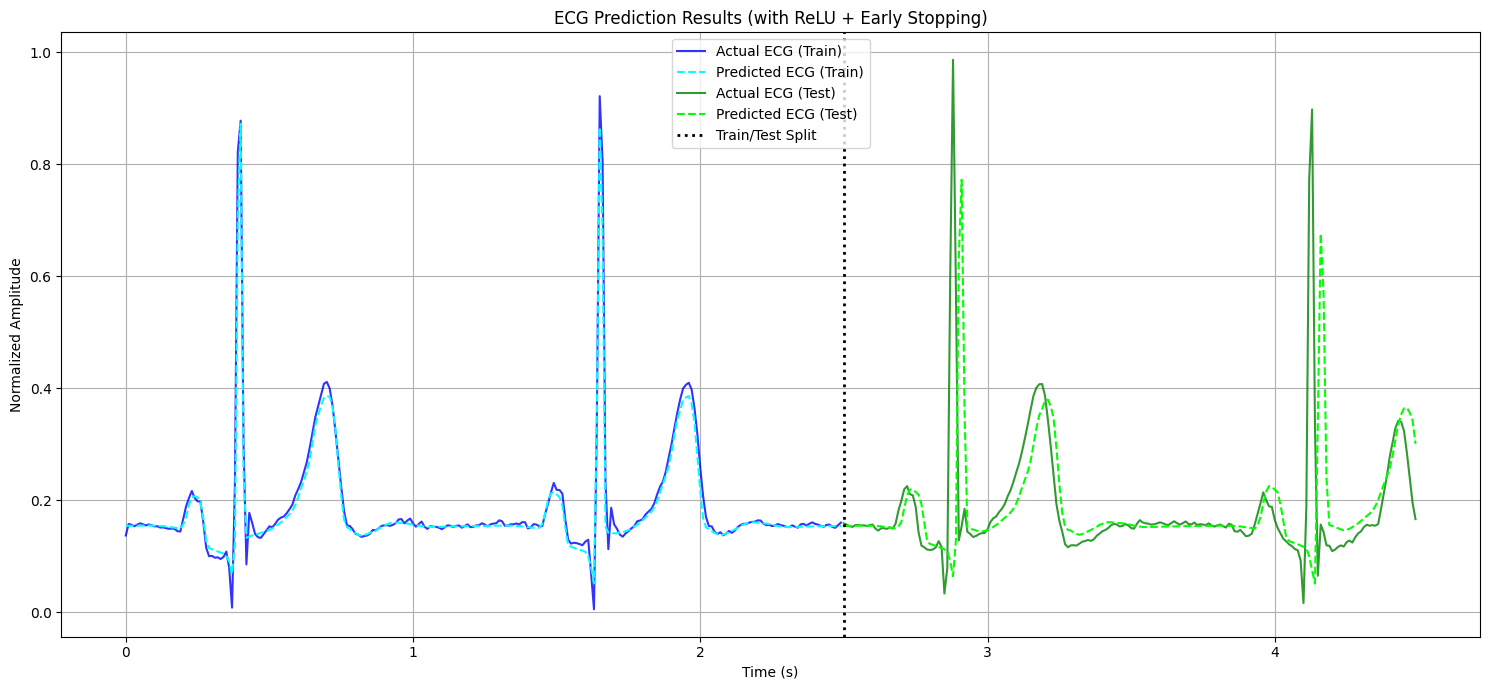

In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5, dt=0.01, alpha=1.0, omega1=5.01, omega2=5.08,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1),
                     R2*np.cos(Phi2),
                     R2*np.sin(phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = downsampled_ecg_base_corrected

    # Setup
    train_duration = 2.5
    total_duration = 4.5
    fs = 100
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
   # val_frac = 0.1
    #val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:train_samples]
    y_train = ecg_target_train[:train_samples]
    X_val = sim_osc_input_train[train_samples:]
    y_val = ecg_target_train[train_samples:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    best_val = float("inf")
    patience, wait = 500, 0
    best_state = None
    num_epochs = 8000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            best_state = heart_model.state_dict()
            wait = 0
        else:
            wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
    if best_state:
        heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Another data

In [32]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')
file_path_corrected = '/content/drive/MyDrive/CAM_CAN_ALternate/CC110087/ica_raw.fif'
file_new_raw= '/content/drive/MyDrive/CAM_CAN_ALternate/CC110087/transdef_mf2pt2_rest_raw.fif'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import mne
raw = mne.io.read_raw_fif(file_new_raw)
print(raw)
#import mne

raw = mne.io.read_raw_fif(file_new_raw, preload=True)  # preload=True loads data into memory

data = raw.get_data()  # shape is (n_channels, n_times)
print(f"Data shape: {data.shape}")

n_channels, n_times = data.shape
print(f"Number of channels: {n_channels}")
print(f"Number of time points: {n_times}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {n_times / raw.info['sfreq']} seconds")

print(raw.get_channel_types())


Opening raw data file /content/drive/MyDrive/CAM_CAN_ALternate/CC110087/transdef_mf2pt2_rest_raw.fif...
    Range : 92000 ... 655999 =     92.000 ...   655.999 secs
Ready.
<Raw | transdef_mf2pt2_rest_raw.fif, 338 x 564000 (564.0 s), ~6.3 MiB, data not loaded>
Opening raw data file /content/drive/MyDrive/CAM_CAN_ALternate/CC110087/transdef_mf2pt2_rest_raw.fif...
    Range : 92000 ... 655999 =     92.000 ...   655.999 secs
Ready.
Reading 0 ... 563999  =      0.000 ...   563.999 secs...
Data shape: (338, 564000)
Number of channels: 338
Number of time points: 564000
Sampling frequency: 1000.0 Hz
Duration: 564.0 seconds
['grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 'grad', 'mag', 'grad', 

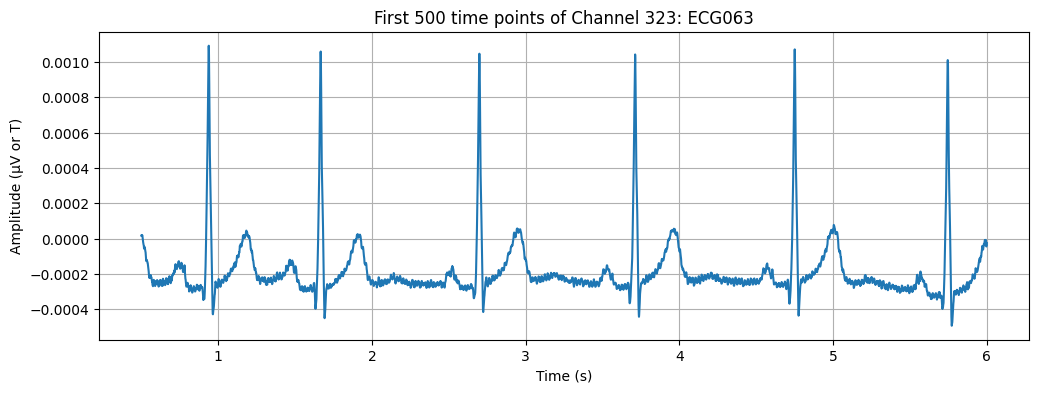

In [61]:
import matplotlib.pyplot as plt

# Get the sampling frequency
sfreq = 1000

# Extract 323rd channel and first 500 samples (Python index 322)
data, times = raw[322,500:6000]  # shape of data is (1, 500)
data=-data

# Get channel name
channel_name = raw.ch_names[322]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(times, data[0])
plt.title(f"First 500 time points of Channel 323: {channel_name}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV or T)")
plt.grid(True)
plt.show()


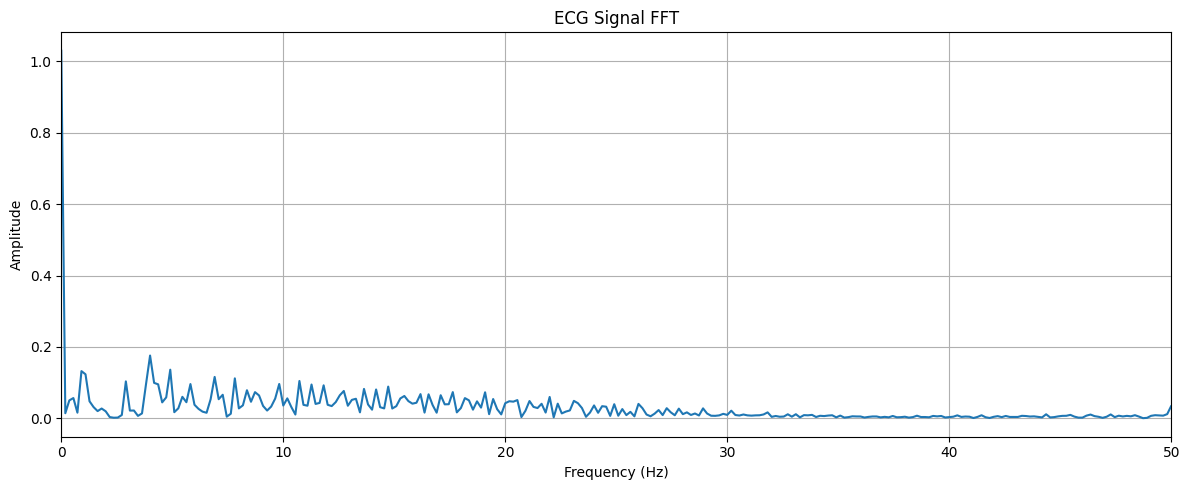

(5500,)


In [62]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Load raw CamCAN MEG data (replace with actual file path)
#raw = mne.io.read_raw_fif("path_to_camcan_raw.fif", preload=True)

# Pick the ECG channel (usually named 'ECG 001')
#raw_ecg = data

# Get ECG signal data and sampling frequency
ecg_data = data[0] # Shape: (n_times,)
sfreq = 1000
n_samples = ecg_data.shape[0]

# Compute FFT
fft_vals = np.fft.rfft(ecg_data)
fft_freqs = np.fft.rfftfreq(n_samples, d=1/sfreq)

# Convert amplitude to dB or use absolute
fft_amplitude = np.abs(fft_vals)

# Plot FFT
plt.figure(figsize=(12, 5))
plt.plot(fft_freqs, fft_amplitude)
plt.title("ECG Signal FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 50)  # ECG mostly lies below 40 Hz
plt.grid(True)
plt.tight_layout()
plt.show()
print(ecg_data.shape)

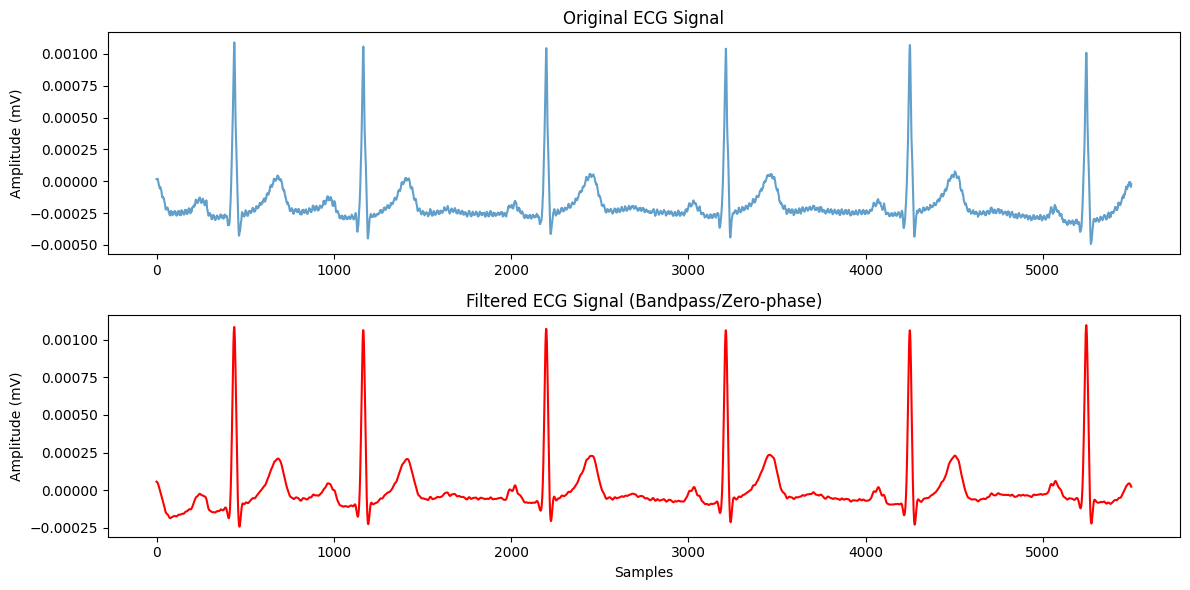

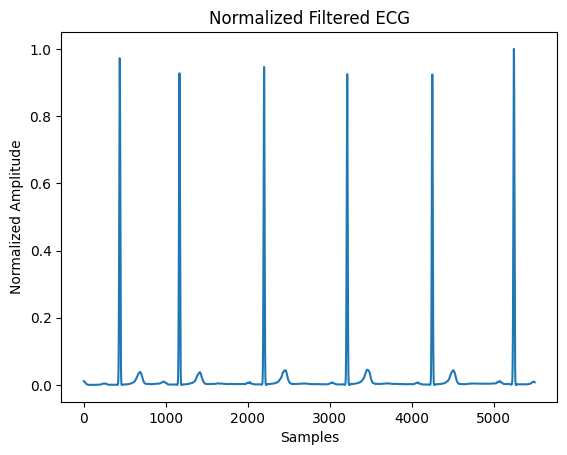

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Replace with your actual ECG data as a 1D NumPy array
# ecg_data = np.array([...])  # Your ECG signal here

# Parameters (edit if needed)
fs = 1000
Fs= 1000    # Sampling frequency in Hz
lowcut = 0.65     # Lower cutoff for bandpass filter (Hz)
highcut = 40.0   # Upper cutoff for bandpass filter (Hz)
order = 4      # Butterworth filter order

# Design the filter
b, a = butter(order, [lowcut/(0.5*fs), highcut/(0.5*fs)], btype='band')

# Apply bandpass with zero-phase distortion
filtered_ecg = filtfilt(b, a, ecg_data)  ## filtered in _between 0.65 -- 20 HZ.. below that not generating proper ECG signal..

# (Optional) Normalize the filtered signal to [0, 1]
normalized_ecg = ((filtered_ecg - np.min(filtered_ecg)) / (np.max(filtered_ecg) - np.min(filtered_ecg)))**3

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ecg_data, alpha=0.7)
plt.title('Original ECG Signal')
plt.ylabel('Amplitude (mV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_ecg, color='r')
plt.title('Filtered ECG Signal (Bandpass/Zero-phase)')
plt.ylabel('Amplitude (mV)')
plt.xlabel('Samples')
plt.tight_layout()
plt.show()

# (Optional) Plot normalized
plt.figure()
plt.plot(normalized_ecg)
plt.title('Normalized Filtered ECG')
plt.xlabel('Samples')
plt.ylabel('Normalized Amplitude')
plt.show()


In [106]:
def get_median_filter_width(sampling_rate, duration):
    res = int( sampling_rate*duration )
    res += ((res%2) - 1) # needs to be an odd number
    return res
# baseline fitting by filtering
# === Define Filtering Params for Baseline fitting Leads======================
ms_flt_array = [0.2,0.6]    #<-- length of baseline fitting filters (in seconds)
mfa = np.zeros(len(ms_flt_array), dtype='int')
for i in range(0, len(ms_flt_array)):
    mfa[i] = get_median_filter_width(Fs,ms_flt_array[i])

def filter_signal(X):
    global mfa
    X0 = X  #read orignal signal
    for mi in range(0,len(mfa)):
        X0 = medfilt(X0,mfa[mi]) # apply median filter one by one on top of each other
    X0 = np.subtract(X,X0)  # finally subtract from orignal signal
    return X0

signal_flt = filter_signal(filtered_ecg) ## usued filterd_ecg__not normalized one..

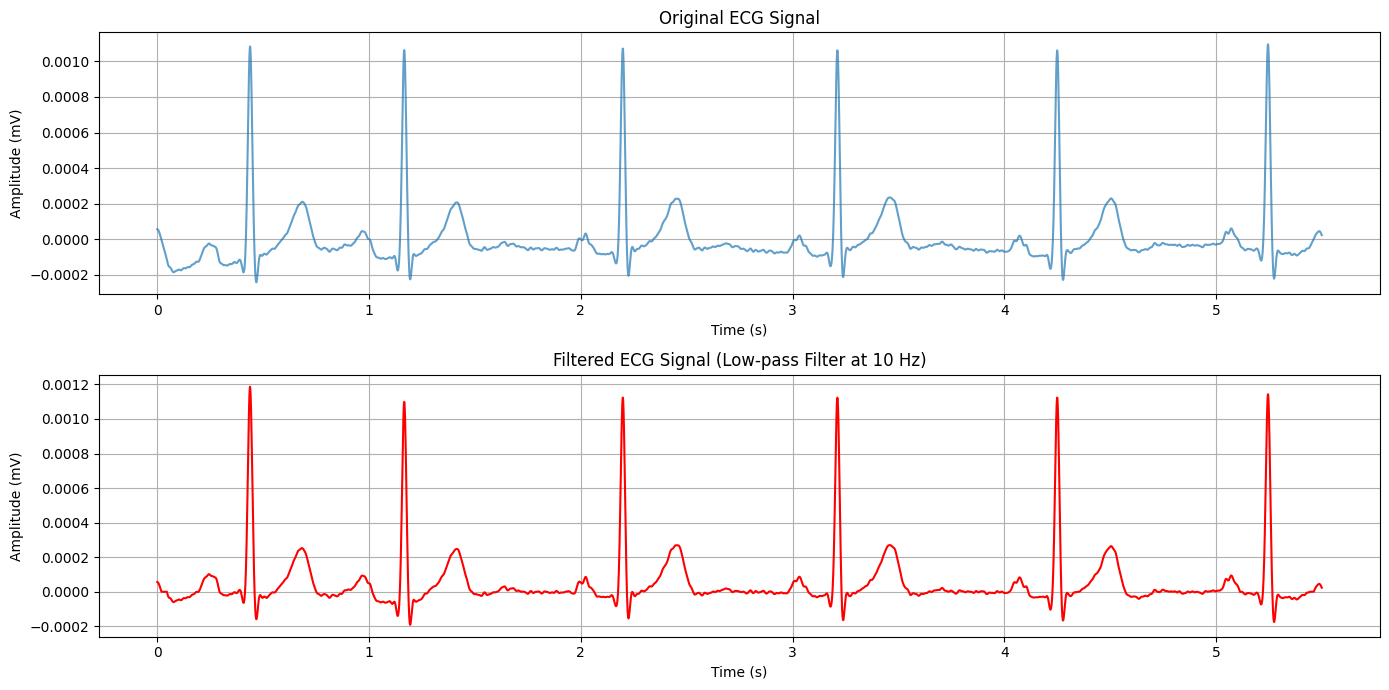

/tmp/ipython-input-3456419443.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 8, loc = 'upper right')


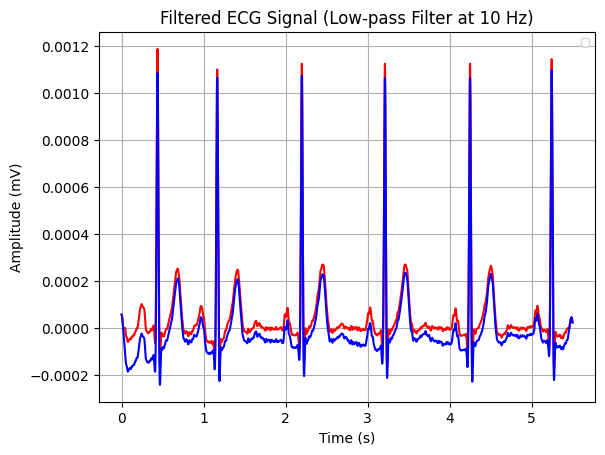

In [107]:
# Plot the original and filtered signals
time_axis = np.arange(len(ecg_data)) / Fs  # Time in seconds
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(time_axis,filtered_ecg, label="Original ECG Signal", alpha=0.7)
plt.title("Original ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time_axis, signal_flt, label="Filtered ECG Signal", color='red')
plt.title("Filtered ECG Signal (Low-pass Filter at 10 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.tight_layout()
plt.show()


plt.plot(time_axis, signal_flt,color='red')
plt.plot(time_axis,filtered_ecg,color='blue')
plt.legend(fontsize = 8, loc = 'upper right')
plt.title("Filtered ECG Signal (Low-pass Filter at 10 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

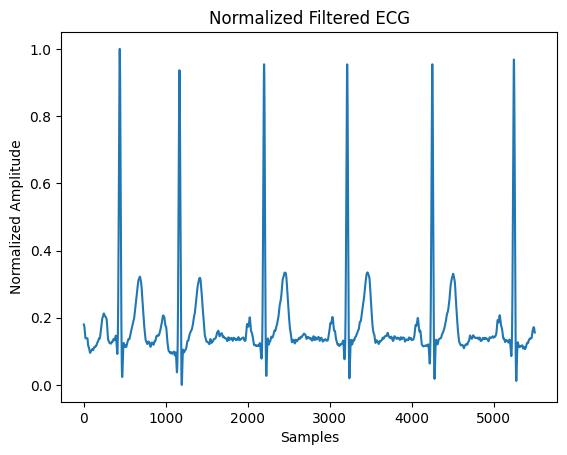

In [108]:
## baseline nomalized..

normalized_ecg_basecorrect = ((signal_flt - np.min(signal_flt)) / (np.max(signal_flt) - np.min(signal_flt))) ## use for modelling behaviour.
plt.figure()
plt.plot(normalized_ecg_basecorrect)
plt.title('Normalized Filtered ECG')
plt.xlabel('Samples')
plt.ylabel('Normalized Amplitude')
plt.show()

Dominant frequency: 0.00 Hz


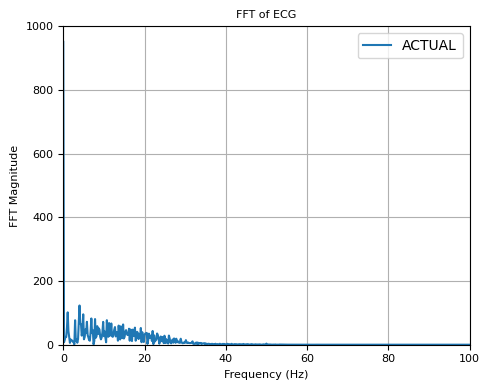

Top Peak Frequencies:
Peak 1: 4.00 Hz, Magnitude: 123.24
Peak 2: 1.09 Hz, Magnitude: 101.63
Peak 3: 4.91 Hz, Magnitude: 95.47
Peak 4: 6.91 Hz, Magnitude: 82.46
Peak 5: 7.82 Hz, Magnitude: 80.64


In [109]:
import numpy as np
from numpy.fft import fft, ifft
from scipy.signal import find_peaks
# FFT computation for STN
sr = 1000
#filtered_ecg_reshaped= ecg_data_reshaped
N_actual = len(normalized_ecg_basecorrect)
ecg_signal = normalized_ecg_basecorrect
freq_actual = np.fft.fftfreq(N_actual, d=1/sr)
fft_output_actual = np.fft.fft(ecg_signal) #Taking fft of the signal, not the reshaped data

# Keep only the positive half of frequencies
N_half = N_actual // 2
freq_actual = freq_actual[:N_half]
fft_magnitude = np.abs(fft_output_actual)[:N_half] #Taking the absolute value for magnitudes

plt.figure(figsize=(5, 4))
plt.plot(freq_actual, fft_magnitude, label='ACTUAL') #Plotting the frequency spectrum
plt.xlim(0, 100)
plt.ylim(0, 1000)
plt.title('FFT of ECG', fontsize=8)
plt.xlabel('Frequency (Hz)', fontsize=8)
plt.ylabel('FFT Magnitude', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.legend()
plt.tight_layout()

# Find the dominant frequency in the positive half
dominant_freq_index = np.argmax(fft_magnitude)
dominant_frequency = freq_actual[dominant_freq_index]
print(f"Dominant frequency: {dominant_frequency:.2f} Hz")

plt.show()


peak_indices, _ = find_peaks(fft_magnitude, height=10)  # Adjust height threshold as needed
peak_frequencies = freq_actual[peak_indices]
peak_magnitudes = fft_magnitude[peak_indices]

# Sort peaks by magnitude (highest first)
sorted_indices = np.argsort(peak_magnitudes)[::-1]
peak_frequencies = peak_frequencies[sorted_indices]
peak_magnitudes = peak_magnitudes[sorted_indices]

# 🎯 Print the top 5 peak frequencies
print("Top Peak Frequencies:")
for i in range(min(5, len(peak_frequencies))):
    print(f"Peak {i+1}: {peak_frequencies[i]:.2f} Hz, Magnitude: {peak_magnitudes[i]:.2f}")

(550,)


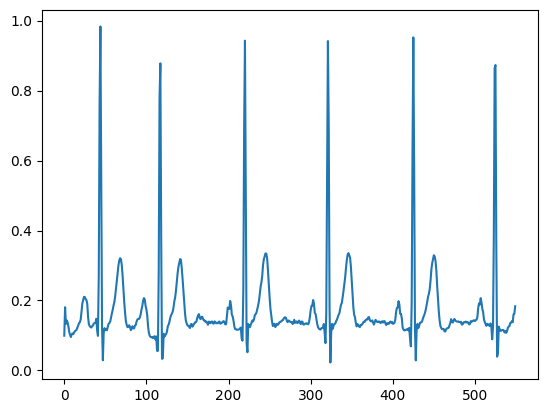

In [110]:
from scipy.signal import decimate

downsampled_ecg_base_corrected = decimate(normalized_ecg_basecorrect, q=10, ftype='fir')  # or 'fir'
print(np.shape(downsampled_ecg_base_corrected))
plt.plot(downsampled_ecg_base_corrected)


--- Using device: cpu ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.013168
Epoch 2000/60000, Loss: 0.012688
Epoch 3000/60000, Loss: 0.012465
Epoch 4000/60000, Loss: 0.011632
Epoch 5000/60000, Loss: 0.010433
Epoch 6000/60000, Loss: 0.007197
Epoch 7000/60000, Loss: 0.005832
Epoch 8000/60000, Loss: 0.005896
Epoch 9000/60000, Loss: 0.005125
Epoch 10000/60000, Loss: 0.005429
Epoch 11000/60000, Loss: 0.006132
Epoch 12000/60000, Loss: 0.005724
Epoch 13000/60000, Loss: 0.005266
Epoch 14000/60000, Loss: 0.005136
Epoch 15000/60000, Loss: 0.005275
Epoch 16000/60000, Loss: 0.005373
Epoch 17000/60000, Loss: 0.005323
Epoch 18000/60000, Loss: 0.005563
Epoch 19000/60000, Loss: 0.005109
Epoch 20000/60000, Loss: 0.005072
Epoch 21000/60000, Loss: 0.004702
Epoch 22000/60000, Loss: 0.004122
Epoch 23000/60000, Loss: 0.004354
Epoch 24000/60000, Loss: 0.003678
Epoch 25000/60000, Loss: 0.004364
Epoch 26000/60000, Loss: 0.003000
Epoch 27000/60000, Loss: 0.003437
Epoch 28000/60000, Loss: 0

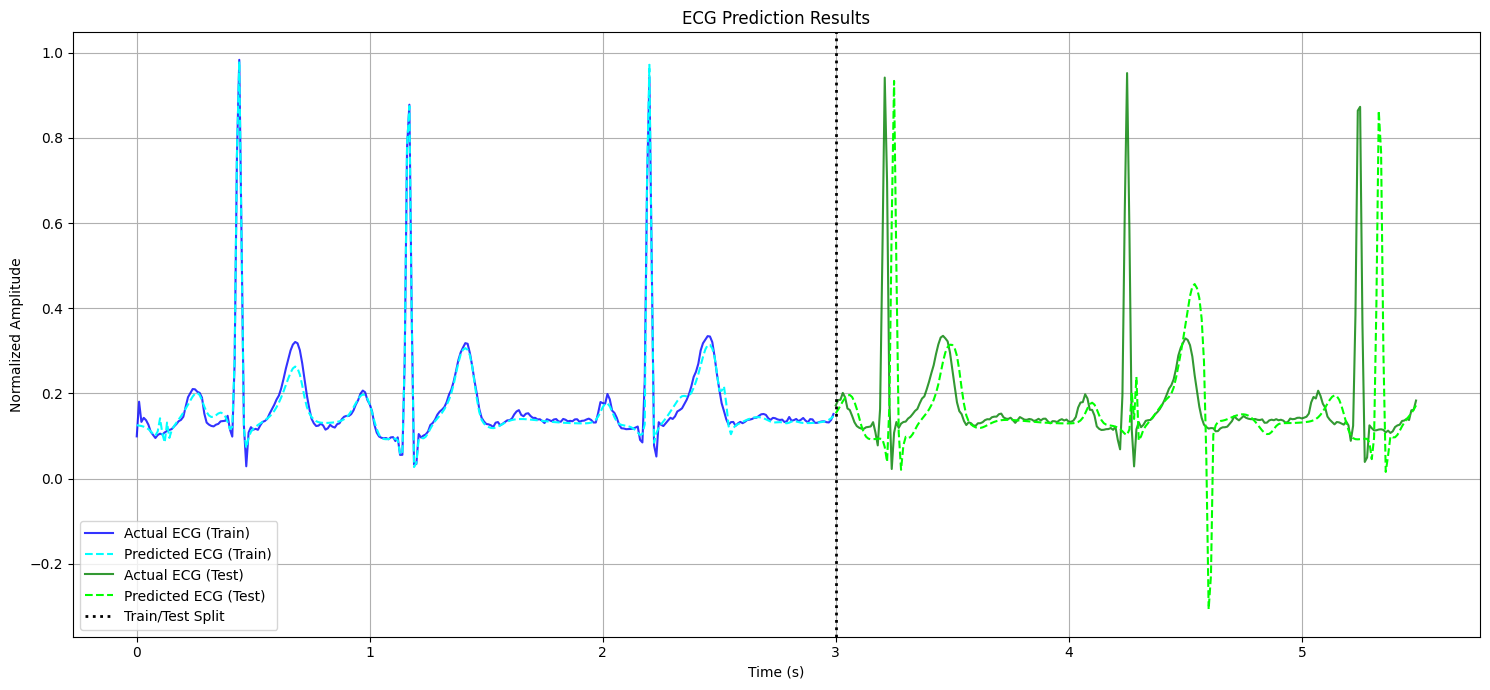

In [111]:
def simulate_coupled_oscillators(T=5.5, dt=0.01, alpha=1.0, omega1=3.01, omega2=3.02, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = downsampled_ecg_base_corrected

    # Time vectors for plotting
    train_duration= 3.0
    total_duration = 5.5
    fs = 100
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [48]:
np.shape(ecg_test)

(250,)

--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.013586, Val=0.001775
Epoch 1000, Train=0.011729, Val=0.005174
Epoch 1500, Train=0.010135, Val=0.006330
Epoch 2000, Train=0.008175, Val=0.006853
Epoch 2500, Train=0.006789, Val=0.006368
Epoch 3000, Train=0.006154, Val=0.006158
Epoch 3500, Train=0.005428, Val=0.006010
Epoch 4000, Train=0.004711, Val=0.006303
Epoch 4500, Train=0.004165, Val=0.006615
Epoch 5000, Train=0.003592, Val=0.006235
Epoch 5500, Train=0.003262, Val=0.006431
Epoch 6000, Train=0.003144, Val=0.006601
Epoch 6500, Train=0.003113, Val=0.006547
Epoch 7000, Train=0.002990, Val=0.006774
Epoch 7500, Train=0.002553, Val=0.006583
Epoch 8000, Train=0.002601, Val=0.006895
Epoch 8500, Train=0.002320, Val=0.006790
Epoch 9000, Train=0.002112, Val=0.006672
Epoch 9500, Train=0.001773, Val=0.006731
Epoch 10000, Train=0.001447, Val=0.006628
--- Training Finished ---



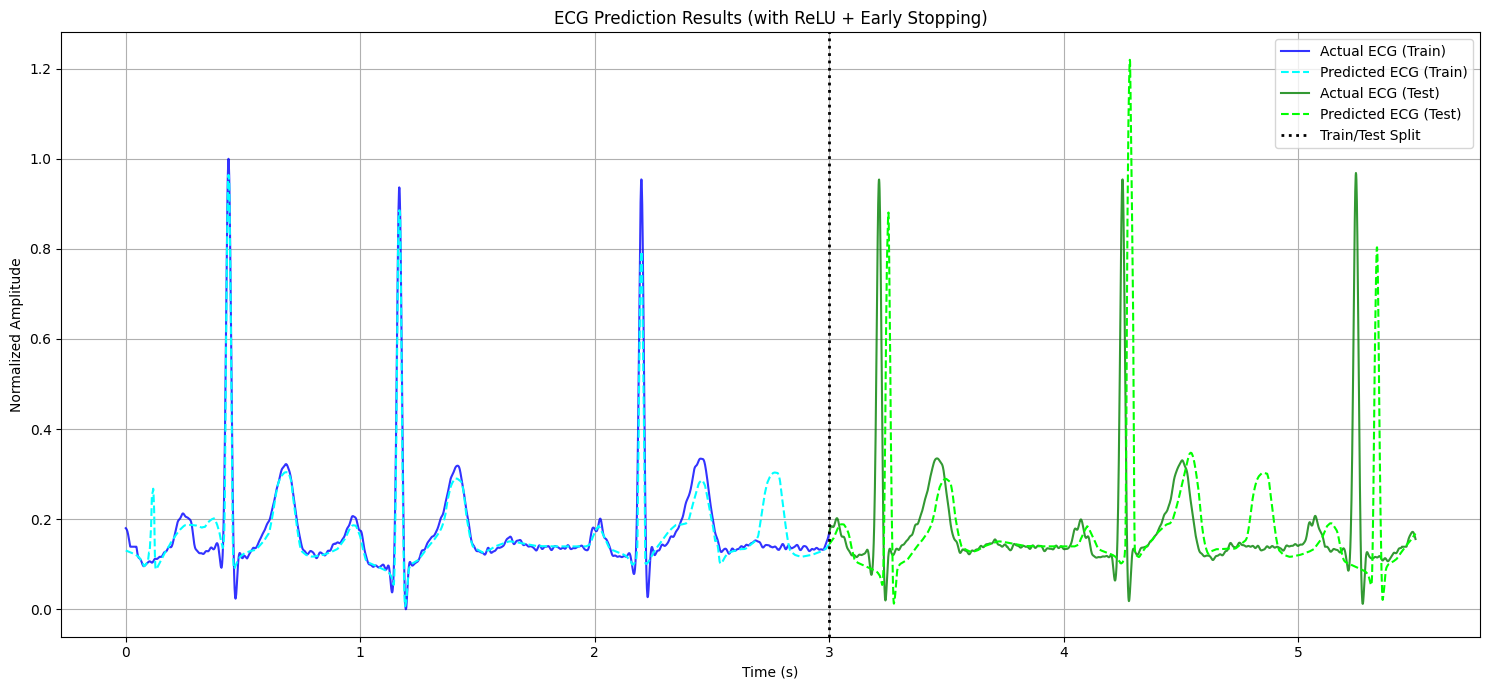

In [71]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5.5, dt=0.001, alpha=1.0, omega1=3.01, omega2=3.02,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),R1*np.sin(Phi1),
                     R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 3
    total_duration = 5.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    #best_val = float("inf")
    #patience, wait = 500, 0
    #best_state = None
    num_epochs =10000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        #if val_loss.item() < best_val:
         #   best_val = val_loss.item()
          #  best_state = heart_model.state_dict()
          #  wait = 0
        #else:
         #   wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
   # if best_state:
    #    heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.013819, Val=0.001462
Epoch 1000, Train=0.012728, Val=0.003847
Epoch 1500, Train=0.011191, Val=0.004897
Epoch 2000, Train=0.009103, Val=0.005594
Epoch 2500, Train=0.007166, Val=0.005547
Epoch 3000, Train=0.006289, Val=0.005527
Epoch 3500, Train=0.005540, Val=0.005755
Epoch 4000, Train=0.005373, Val=0.005723
Epoch 4500, Train=0.005147, Val=0.005845
Epoch 5000, Train=0.004038, Val=0.005660
Epoch 5500, Train=0.003715, Val=0.005714
Epoch 6000, Train=0.003270, Val=0.005833
Epoch 6500, Train=0.002710, Val=0.005505
Epoch 7000, Train=0.002544, Val=0.005817
Epoch 7500, Train=0.002433, Val=0.005906
Epoch 8000, Train=0.001990, Val=0.005744
Epoch 8500, Train=0.001717, Val=0.005764
Epoch 9000, Train=0.001762, Val=0.005666
Epoch 9500, Train=0.001531, Val=0.005853
Epoch 10000, Train=0.001744, Val=0.005761
--- Training Finished ---



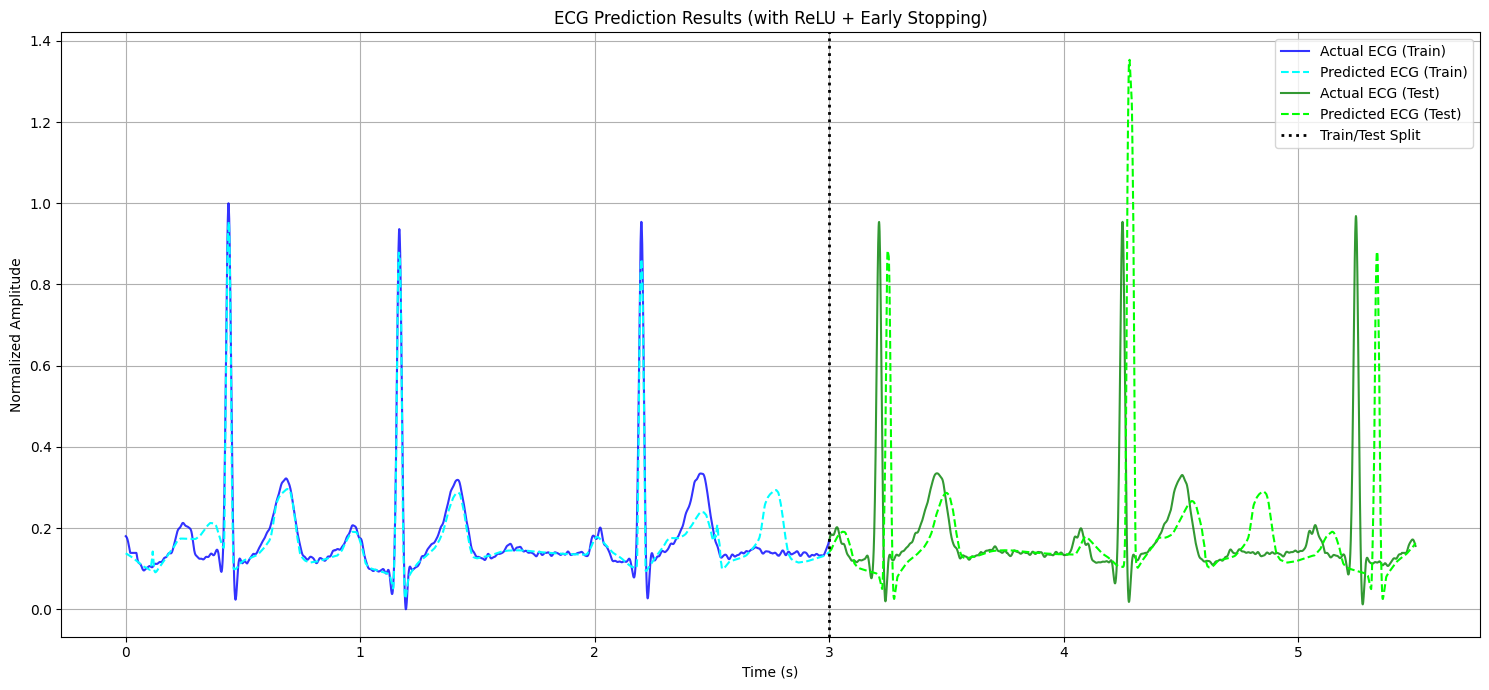

In [112]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5.5, dt=0.001, alpha=1.0, omega1=3.01, omega2=3.02,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),R1*np.sin(Phi1),
                     R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect

    # Setup
    train_duration = 3
    total_duration = 5.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    #best_val = float("inf")
    #patience, wait = 500, 0
    #best_state = None
    num_epochs =10000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        #if val_loss.item() < best_val:
         #   best_val = val_loss.item()
          #  best_state = heart_model.state_dict()
          #  wait = 0
        #else:
         #   wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
   # if best_state:
    #    heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Using device: cpu ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.012950
Epoch 2000/60000, Loss: 0.012646
Epoch 3000/60000, Loss: 0.011916
Epoch 4000/60000, Loss: 0.012136
Epoch 5000/60000, Loss: 0.011787
Epoch 6000/60000, Loss: 0.011075
Epoch 7000/60000, Loss: 0.010545
Epoch 8000/60000, Loss: 0.010568
Epoch 9000/60000, Loss: 0.007947
Epoch 10000/60000, Loss: 0.005360
Epoch 11000/60000, Loss: 0.005391
Epoch 12000/60000, Loss: 0.004591
Epoch 13000/60000, Loss: 0.005167
Epoch 14000/60000, Loss: 0.004338
Epoch 15000/60000, Loss: 0.004539
Epoch 16000/60000, Loss: 0.004599
Epoch 17000/60000, Loss: 0.004021
Epoch 18000/60000, Loss: 0.004201
Epoch 19000/60000, Loss: 0.003824
Epoch 20000/60000, Loss: 0.003640
Epoch 21000/60000, Loss: 0.003685
Epoch 22000/60000, Loss: 0.003411
Epoch 23000/60000, Loss: 0.003186
Epoch 24000/60000, Loss: 0.003282
Epoch 25000/60000, Loss: 0.002880
Epoch 26000/60000, Loss: 0.003115
Epoch 27000/60000, Loss: 0.004358
Epoch 28000/60000, Loss: 0

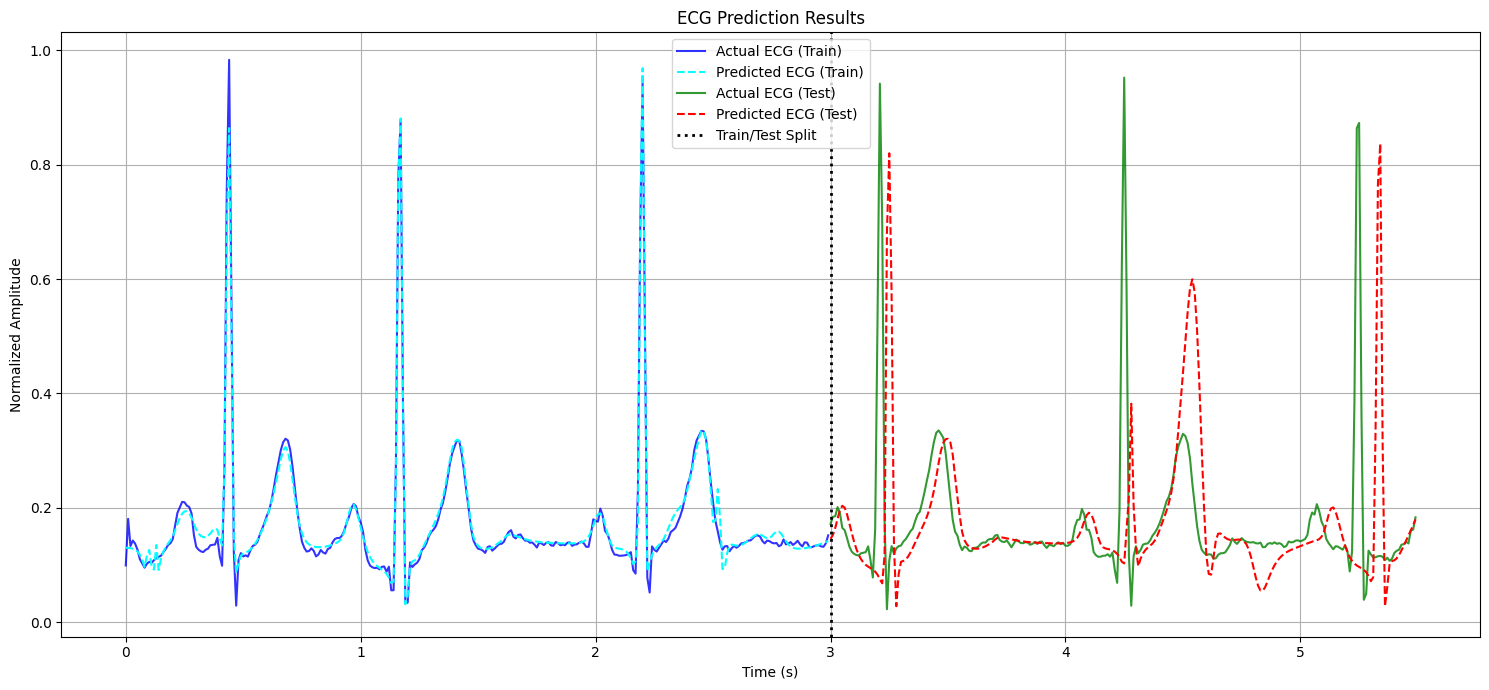

In [96]:
def simulate_coupled_oscillators(T=5.5, dt=0.01, alpha=1.0, omega1=3.01, omega2=3.02, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = downsampled_ecg_base_corrected

    # Time vectors for plotting
    train_duration= 3.0
    total_duration = 5.5
    fs = 100
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='red', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--- Using device: cpu ---

--- Starting Heart Model Training ---
Epoch 1000/60000, Loss: 0.013166
Epoch 2000/60000, Loss: 0.012535
Epoch 3000/60000, Loss: 0.011302
Epoch 4000/60000, Loss: 0.010048
Epoch 5000/60000, Loss: 0.009069
Epoch 6000/60000, Loss: 0.008112
Epoch 7000/60000, Loss: 0.010065
Epoch 8000/60000, Loss: 0.006532
Epoch 9000/60000, Loss: 0.006110
Epoch 10000/60000, Loss: 0.005697
Epoch 11000/60000, Loss: 0.005389
Epoch 12000/60000, Loss: 0.005122
Epoch 13000/60000, Loss: 0.004884
Epoch 14000/60000, Loss: 0.004661
Epoch 15000/60000, Loss: 0.004444
Epoch 16000/60000, Loss: 0.004231
Epoch 17000/60000, Loss: 0.004019
Epoch 18000/60000, Loss: 0.003800
Epoch 19000/60000, Loss: 0.003573
Epoch 20000/60000, Loss: 0.003337
Epoch 21000/60000, Loss: 0.003106
Epoch 22000/60000, Loss: 0.002885
Epoch 23000/60000, Loss: 0.002688
Epoch 24000/60000, Loss: 0.002506
Epoch 25000/60000, Loss: 0.002340
Epoch 26000/60000, Loss: 0.003210
Epoch 27000/60000, Loss: 0.002616
Epoch 28000/60000, Loss: 0

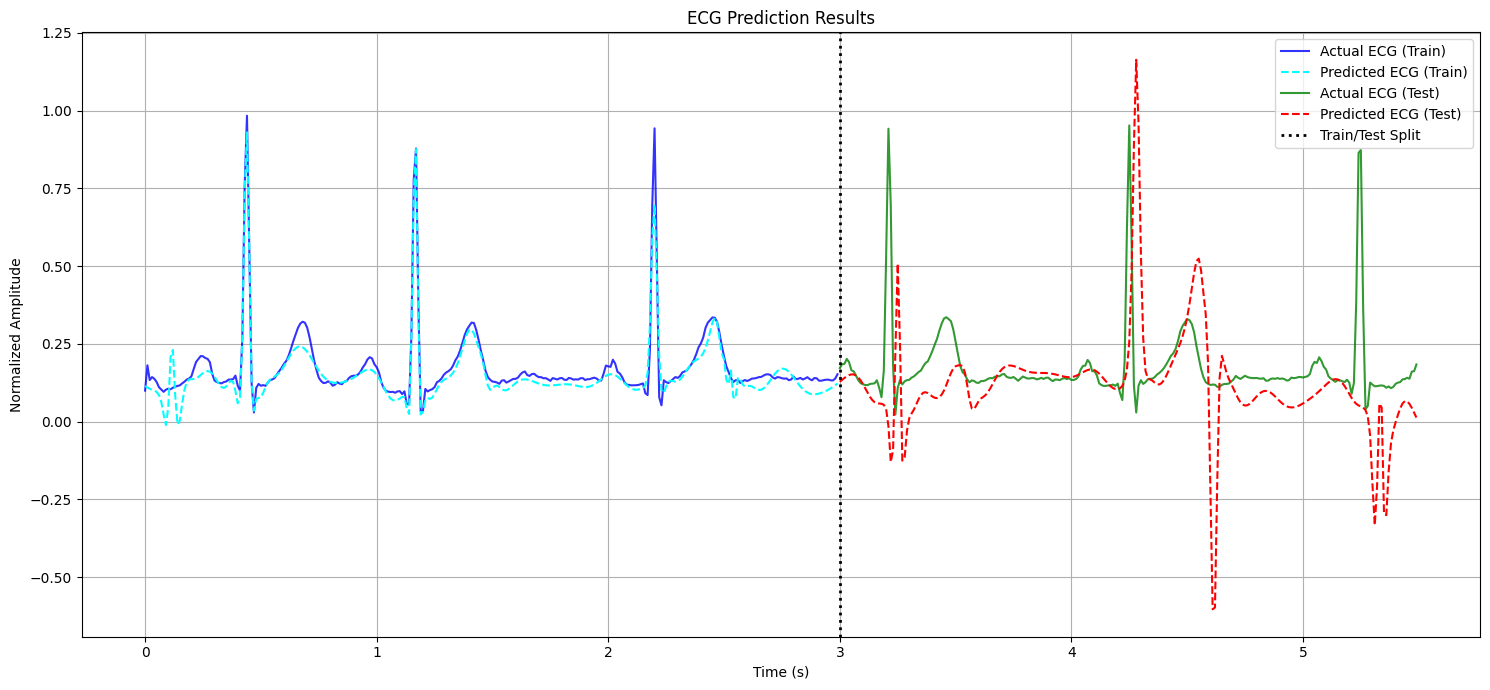

In [104]:
def simulate_coupled_oscillators(T=5.5, dt=0.01, alpha=1.0, omega1=3.01, omega2=3.02, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.Sigmoid(),
            #nn.Dropout(0.1),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---

if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = downsampled_ecg_base_corrected

    # Time vectors for plotting
    train_duration= 3.0
    total_duration = 5.5
    fs = 100
    t_train = np.arange(0, train_duration, 1/fs)
    t_test = np.arange(train_duration, total_duration, 1/fs)
    t_full = np.arange(0, total_duration, 1/fs)

    # 2. Split data into training and testing sets
    train_samples = len(t_train)
    ecg_train = ecg_processed[:train_samples].copy() # Added .copy()
    ecg_test = ecg_processed[train_samples:].copy() # Added .copy()

    # 3. Initialize model, optimizer, and loss function
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_train = torch.tensor(
        simulate_coupled_oscillators(T=train_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)

    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 60000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)
        sim_osc_input_full = torch.tensor(
            simulate_coupled_oscillators(T=total_duration, dt=1/fs),
            dtype=torch.float32
        ).to(device)

        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:]

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='red', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

========= I need to find a good preprocessing steps

In [97]:
import datetime
import os
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import signal
from scipy.signal import medfilt
!pip install PyWavelets
import pywt
from pywt import wavedec

In [103]:
def denoise_signal(X, dwt_transform, dlevels, cutoff_low, cutoff_high):
    coeffs = wavedec(X, dwt_transform, level=dlevels)   # wavelet transform 'bior4.4'
    # scale 0 to cutoff_low
    for ca in range(0,int(cutoff_low)):
        coeffs[ca]=np.multiply(coeffs[ca],[0.0])
    # scale cutoff_high to end
    for ca in range(cutoff_high, len(coeffs)):
        coeffs[ca]=np.multiply(coeffs[ca],[0.0])
    Y = pywt.waverec(coeffs, dwt_transform) # inverse wavelet transform
    return Y

signal_den = denoise_signal(ecg_data,'bior4.4', 7 ,0.65 , 6) #<--- trade off - the less t

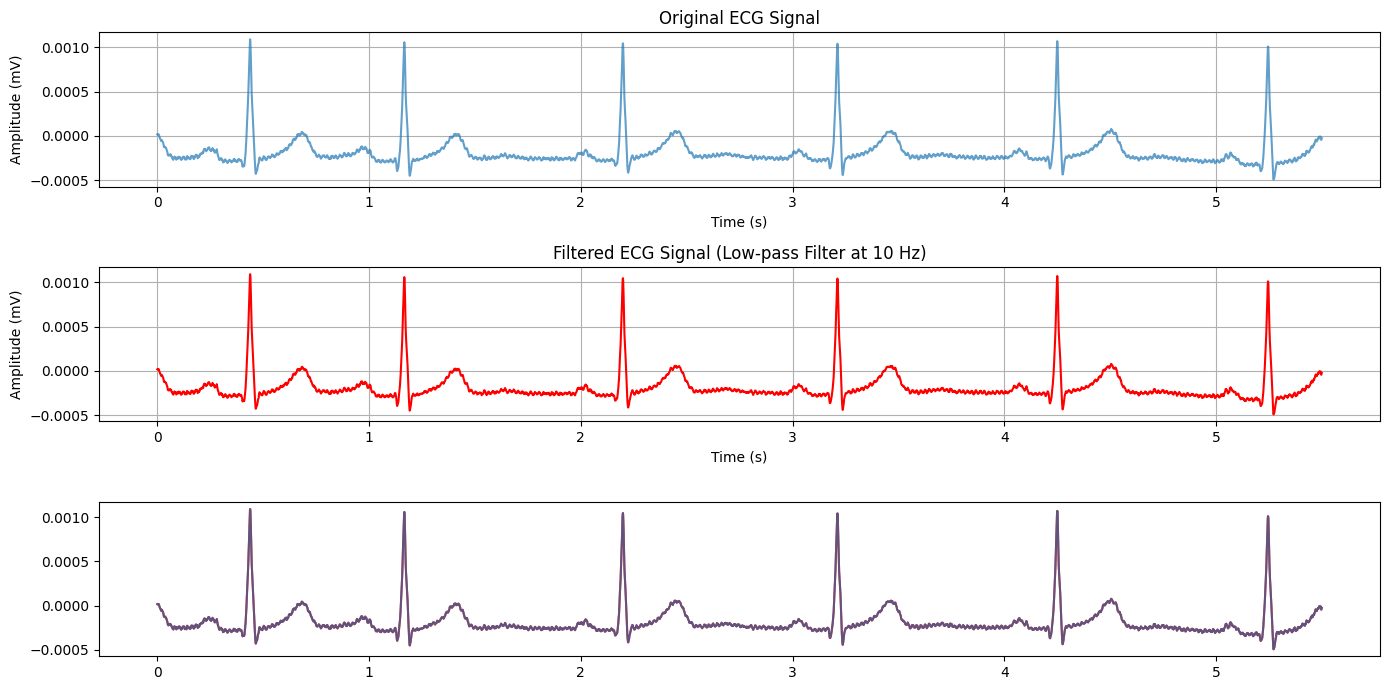

In [101]:
plt.figure(figsize=(14, 7))
plt.subplot(3, 1, 1)
plt.plot(time_axis, ecg_data, label="Original ECG Signal", alpha=0.7)
plt.title("Original ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time_axis, signal_den, label="Filtered ECG Signal", color='red')
plt.title("Filtered ECG Signal (Low-pass Filter at 10 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()



plt.subplot(3, 1, 3)
plt.plot(time_axis,signal_den, label="Filtered ECG Signal", color='red')
plt.plot(time_axis, ecg_data, label="Original ECG Signal", alpha=0.7)
plt.tight_layout()
plt.show()


## Neurokit SOLUTION...

In [115]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 18.5 MB/s eta 0:00:00


In [116]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

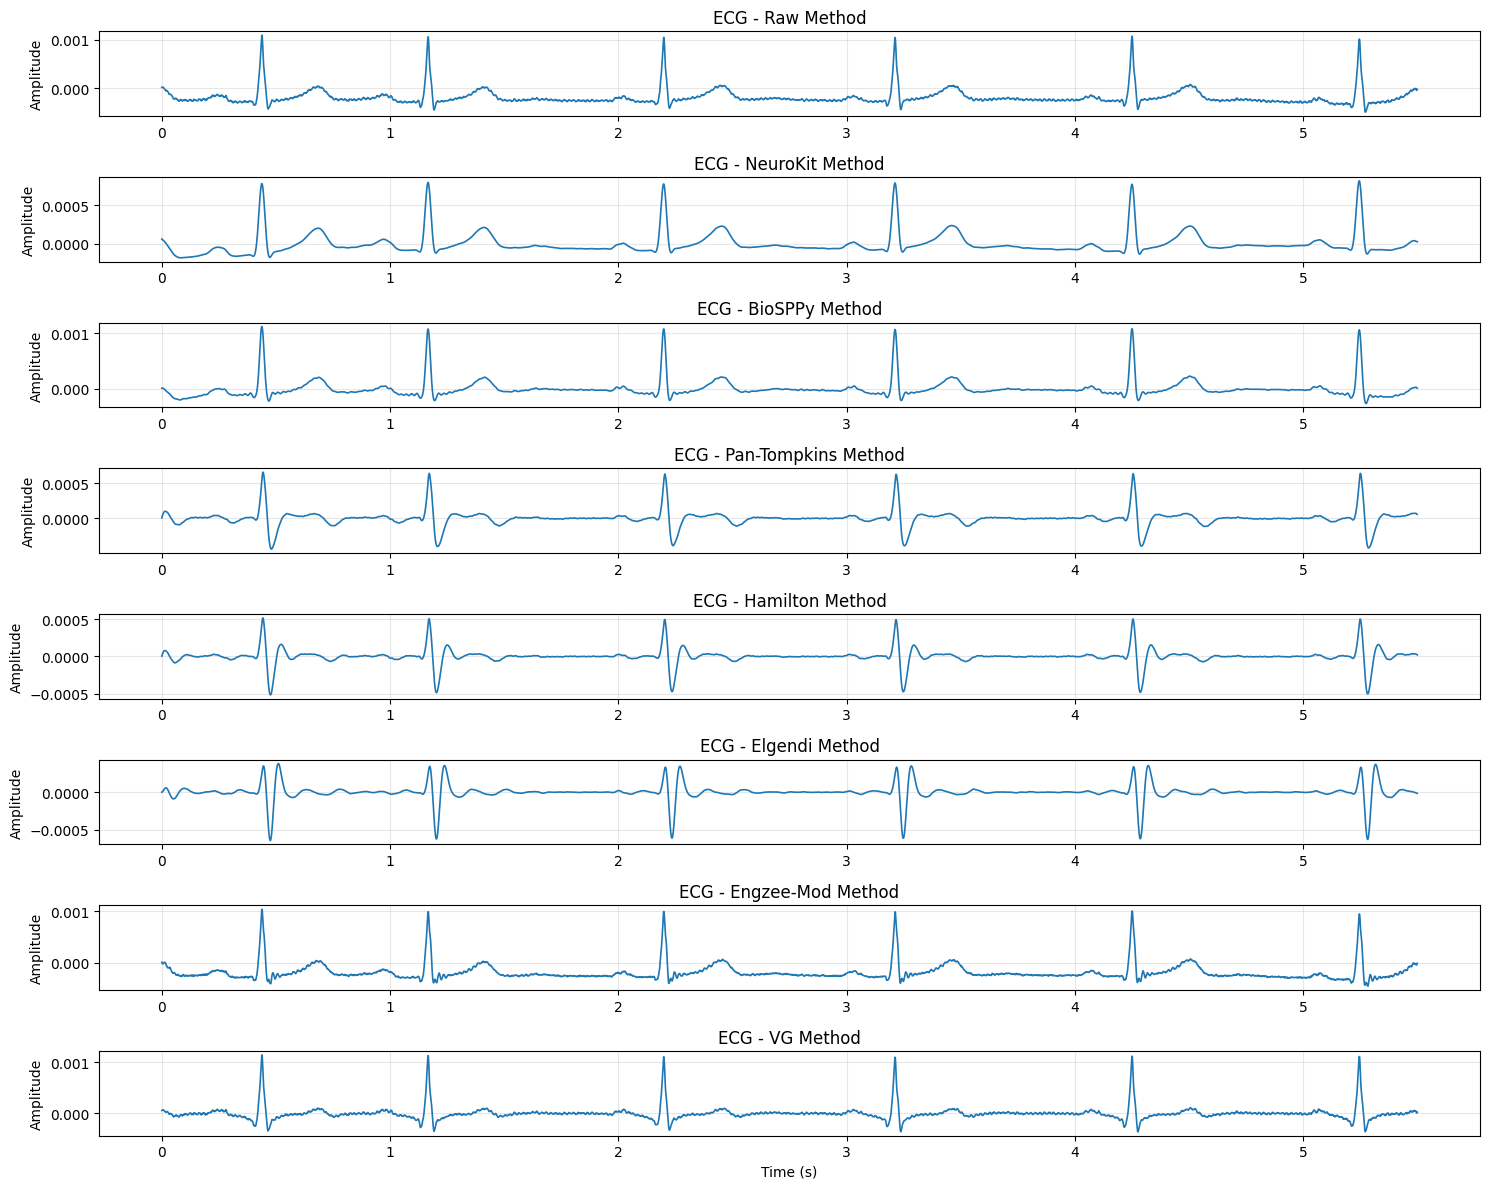

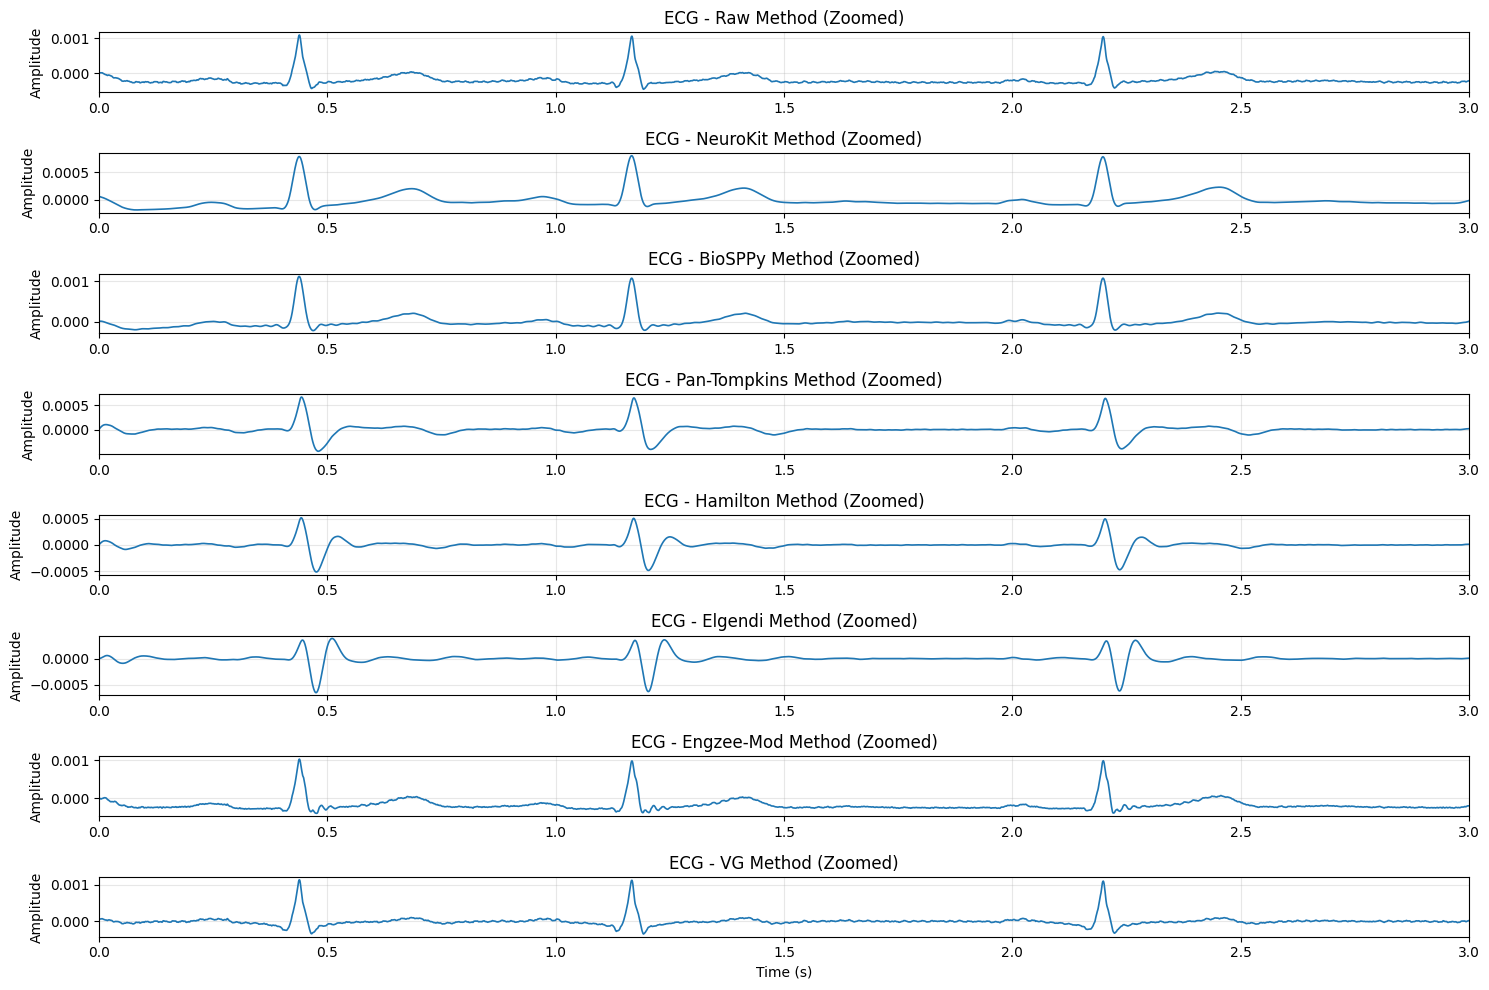

In [126]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def comprehensive_ecg_cleaning_demo(ecg_signal, sampling_rate=1000):
    """
    Comprehensive demonstration of all ECG cleaning methods in NeuroKit2
    """

    # Dictionary to store all cleaned signals
    cleaned_signals = {}

    # Method 1: NeuroKit (Default)
    cleaned_signals['Raw'] = ecg_signal
    cleaned_signals['NeuroKit'] = nk.ecg_clean(ecg_signal, sampling_rate, method="neurokit")

    # Method 2: BioSPPy
    cleaned_signals['BioSPPy'] = nk.ecg_clean(ecg_signal, sampling_rate, method="biosppy")

    # Method 3: Pan & Tompkins
    cleaned_signals['Pan-Tompkins'] = nk.ecg_clean(ecg_signal, sampling_rate, method="pantompkins1985")

    # Method 4: Hamilton
    cleaned_signals['Hamilton'] = nk.ecg_clean(ecg_signal, sampling_rate, method="hamilton2002")

    # Method 5: Elgendi
    cleaned_signals['Elgendi'] = nk.ecg_clean(ecg_signal, sampling_rate, method="elgendi2010")

    # Method 6: Engelse & Zeelenberg Modified
    cleaned_signals['Engzee-Mod'] = nk.ecg_clean(ecg_signal, sampling_rate, method="engzeemod2012")

    # Method 7: Visibility Graph (if available)
    try:
        cleaned_signals['VG'] = nk.ecg_clean(ecg_signal, sampling_rate, method="vg")
    except:
        print("VG method not available in this version")

    return cleaned_signals

# Load or simulate ECG data
#ecg = nk.ecg_simulate(duration=10, sampling_rate=1000, noise=0.1)  # Add some noise
sampling_rate = 1000

# Apply all cleaning methods
cleaned_signals = comprehensive_ecg_cleaning_demo(ecg_data, sampling_rate)

# Convert to DataFrame for easy plotting
df_signals = pd.DataFrame(cleaned_signals)

# Plot comparison
plt.figure(figsize=(15, 12))
n_methods = len(cleaned_signals)

for i, (method_name, signal) in enumerate(cleaned_signals.items()):
    plt.subplot(n_methods, 1, i+1)
    time = np.arange(len(signal)) / sampling_rate
    plt.plot(time, signal, linewidth=1.2)
    plt.title(f'ECG - {method_name} Method')
    plt.ylabel('Amplitude')
    if i == len(cleaned_signals) - 1:
        plt.xlabel('Time (s)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoomed-in comparison (first 3 seconds)
plt.figure(figsize=(15, 10))
time_zoom = np.arange(3000) / sampling_rate  # First 3 seconds

for i, (method_name, signal) in enumerate(cleaned_signals.items()):
    plt.subplot(n_methods, 1, i+1)
    plt.plot(time_zoom, signal[:3000], linewidth=1.2)
    plt.title(f'ECG - {method_name} Method (Zoomed)')
    plt.ylabel('Amplitude')
    if i == len(cleaned_signals) - 1:
        plt.xlabel('Time (s)')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3)

plt.tight_layout()
plt.show()


Cleaned ECG shape: (5500,)


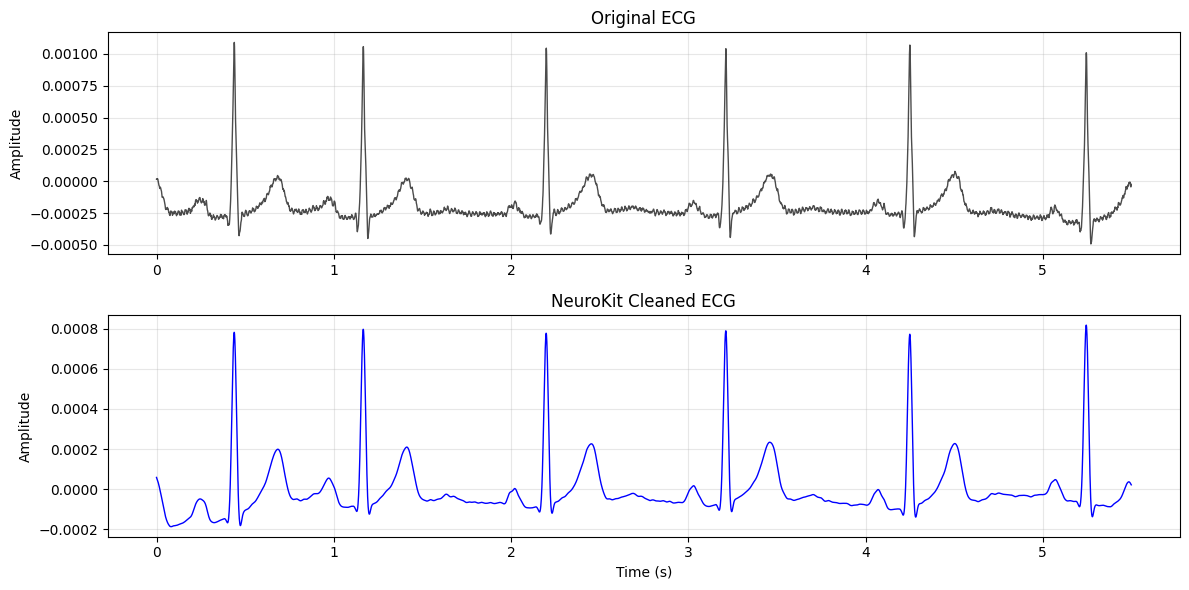

In [127]:
# Clean your ECG data directly with NeuroKit method only
ecg_cleaned_neurokit = nk.ecg_clean(ecg_data, sampling_rate=1000, method="neurokit")

# Save to variable for further use
print(f"Cleaned ECG shape: {ecg_cleaned_neurokit.shape}")

# Quick comparison plot
plt.figure(figsize=(12, 6))
time = np.arange(len(ecg_data)) / sampling_rate

plt.subplot(2, 1, 1)
plt.plot(time, ecg_data, 'k-', alpha=0.7, linewidth=1)
plt.title('Original ECG')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time, ecg_cleaned_neurokit, 'b-', linewidth=1)
plt.title('NeuroKit Cleaned ECG')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

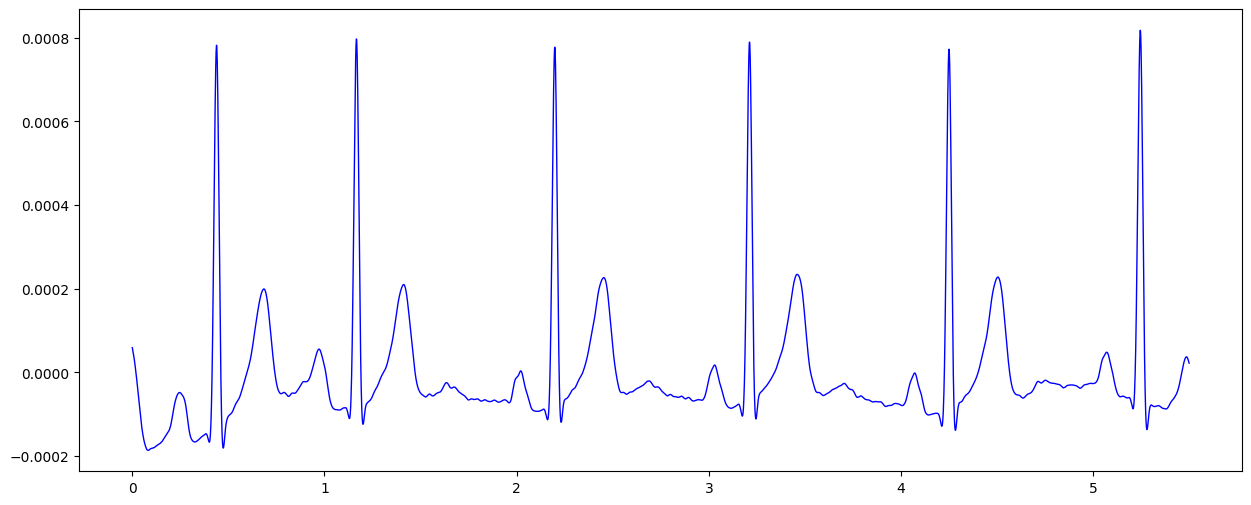

In [122]:
# Get the NeuroKit cleaned data
ecg_clean = ecg_cleaned_neurokit

# Now you can use this for further analysis
# For example, detect R-peaks
peaks, rpeaks = nk.ecg_peaks(ecg_cleaned_neurokit, sampling_rate=1000)

# Calculate heart rate
heart_rate = nk.ecg_rate(rpeaks, sampling_rate=1000, desired_length=len(ecg_cleaned_neurokit))

# Plot with R-peaks marked
plt.figure(figsize=(15, 6))
time = np.arange(len(ecg_clean)) / sampling_rate

plt.plot(time, ecg_clean, 'b-', linewidth=1, label='Cleaned ECG')
plt.plot(time[rpeaks], ecg_clean[rpeaks], 'ro', markersize=4, label='R-peaks')
plt.title('NeuroKit Cleaned ECG with R-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Detected {len(rpeaks)} R-peaks")
print(f"Average heart rate: {np.mean(heart_rate[~np.isnan(heart_rate)]):.1f} BPM")


In [123]:
def advanced_ecg_processing(ecg_signal, sampling_rate=1000, method="neurokit"):
    """
    Complete ECG processing pipeline with cleaning, peak detection, and analysis
    """

    # Step 1: Clean the ECG signal
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate, method=method)

    # Step 2: Detect R-peaks
    peaks, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)

    # Step 3: Calculate heart rate
    heart_rate = nk.ecg_rate(rpeaks, sampling_rate=sampling_rate, desired_length=len(ecg_cleaned))

    # Step 4: Assess signal quality
    quality = nk.ecg_quality(ecg_cleaned, sampling_rate=sampling_rate)

    # Step 5: Delineate ECG waves (P, Q, S, T)
    waves = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_rate)

    # Step 6: Determine cardiac phases
    phases = nk.ecg_phase(ecg_cleaned, rpeaks, sampling_rate=sampling_rate)

    # Combine all signals into a DataFrame
    signals = pd.DataFrame({
        "ECG_Raw": ecg_signal,
        "ECG_Clean": ecg_cleaned,
        "ECG_Rate": heart_rate,
        "ECG_Quality": quality
    })

    # Add peak information
    signals = pd.concat([signals, peaks, waves, phases], axis=1)

    # Create info dictionary
    info = {
        "rpeaks": rpeaks,
        "sampling_rate": sampling_rate,
        "method": method
    }

    return signals, info

# Example usage with different methods
methods_to_test = ["neurokit", "biosppy", "pantompkins1985", "hamilton2002", "elgendi2010"]

results = {}
for method in methods_to_test:
    try:
        signals, info = advanced_ecg_processing(ecg_data, sampling_rate=1000, method=method)
        results[method] = {
            'signals': signals,
            'info': info,
            'n_peaks': len(info['rpeaks'])
        }
        print(f"{method}: {len(info['rpeaks'])} R-peaks detected")
    except Exception as e:
        print(f"Error with {method}: {e}")

# Plot results using NeuroKit's built-in plotting
for method, result in results.items():
    plt.figure(figsize=(15, 8))
    nk.ecg_plot(result['signals'], result['info'])
    plt.suptitle(f'ECG Analysis - {method.upper()} Method', fontsize=14)
    plt.tight_layout()
    plt.show()


Error with neurokit: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid
Error with biosppy: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid
Error with pantompkins1985: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid
Error with hamilton2002: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid
Error with elgendi2010: cannot concatenate object of type '<class 'tuple'>'; only Series and DataFrame objs are valid


TypeError: len() of unsized object

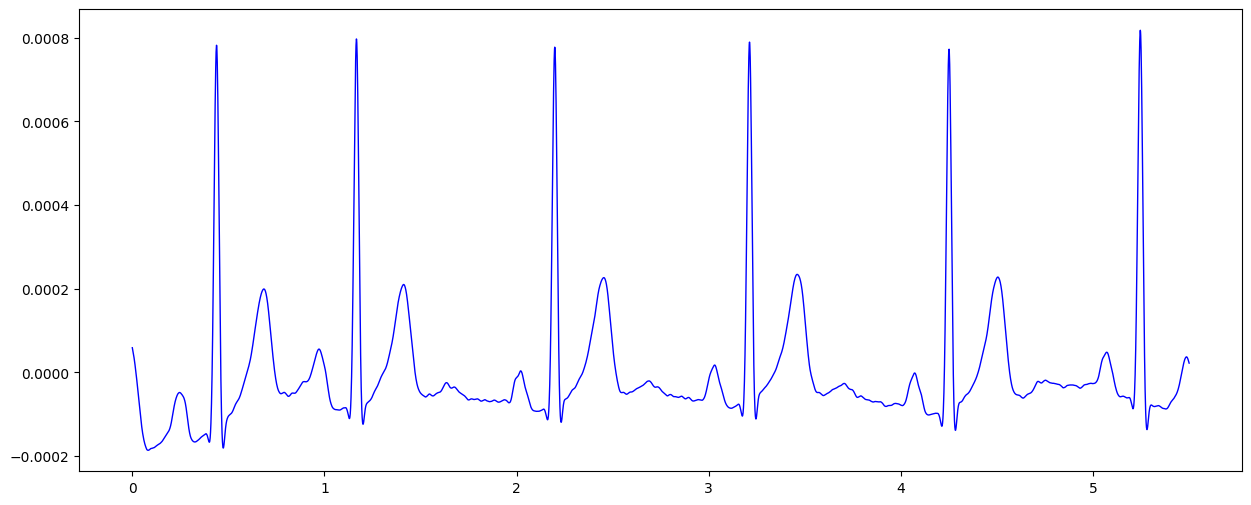

In [130]:
# Most robust approach - convert everything to numpy arrays first
ecg_clean = np.array(cleaned_signals['NeuroKit'])

# Detect peaks
result = nk.ecg_peaks(ecg_clean, sampling_rate=1000)

# Handle the return format (NeuroKit returns tuple)
if isinstance(result, tuple) and len(result) == 2:
    peaks_dict, rpeaks_array = result
    rpeaks = np.array(rpeaks_array)
else:
    print("Unexpected result format from ecg_peaks")
    rpeaks = np.array([])

# Plot safely
plt.figure(figsize=(15, 6))
time_axis = np.linspace(0, len(ecg_clean)/1000, len(ecg_clean))

plt.plot(time_axis, ecg_clean, 'b-', linewidth=1, label='Cleaned ECG')

if len(rpeaks) > 0:
    plt.scatter(time_axis[rpeaks], ecg_clean[rpeaks], c='red', s=30, label='R-peaks', zorder=5)

plt.title('NeuroKit Cleaned ECG with R-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Successfully detected {len(rpeaks)} R-peaks")


In [131]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def advanced_ecg_processing_fixed(ecg_signal, sampling_rate=1000, method="neurokit"):
    """
    Robust ECG processing pipeline with proper error handling
    """

    # Ensure input is numpy array
    if not isinstance(ecg_signal, np.ndarray):
        ecg_signal = np.array(ecg_signal)

    try:
        # Step 1: Clean the ECG signal
        ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate, method=method)
        ecg_cleaned = np.array(ecg_cleaned)

        # Step 2: Detect R-peaks with error handling
        peaks_result = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
        if isinstance(peaks_result, tuple) and len(peaks_result) == 2:
            peaks_dict, rpeaks = peaks_result
        else:
            peaks_dict = peaks_result
            rpeaks = peaks_dict.get('ECG_R_Peaks', []) if isinstance(peaks_dict, dict) else []

        rpeaks = np.array(rpeaks) if hasattr(rpeaks, '__len__') else np.array([])

        # Step 3: Calculate heart rate (with error handling)
        try:
            heart_rate = nk.ecg_rate(rpeaks, sampling_rate=sampling_rate, desired_length=len(ecg_cleaned))
            heart_rate = np.array(heart_rate) if hasattr(heart_rate, '__len__') else np.full(len(ecg_cleaned), np.nan)
        except:
            heart_rate = np.full(len(ecg_cleaned), np.nan)

        # Step 4: Assess signal quality (with fallback)
        try:
            quality = nk.ecg_quality(ecg_cleaned, sampling_rate=sampling_rate)
            quality = np.array(quality) if hasattr(quality, '__len__') else np.full(len(ecg_cleaned), quality)
        except:
            quality = np.full(len(ecg_cleaned), 0.5)  # Default medium quality

        # Step 5: Delineate ECG waves (optional, often causes errors)
        try:
            waves = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_rate)
            # Convert waves dict to DataFrame-compatible format
            if isinstance(waves, dict):
                waves_data = {}
                for key, values in waves.items():
                    if hasattr(values, '__len__') and len(values) == len(ecg_cleaned):
                        waves_data[key] = np.array(values)
                waves = pd.DataFrame(waves_data) if waves_data else pd.DataFrame()
            else:
                waves = pd.DataFrame()
        except:
            print(f"Wave delineation failed for {method}, skipping...")
            waves = pd.DataFrame()

        # Step 6: Determine cardiac phases (optional)
        try:
            phases = nk.ecg_phase(ecg_cleaned, rpeaks, sampling_rate=sampling_rate)
            phases = pd.DataFrame({'ECG_Phase': np.array(phases)}) if hasattr(phases, '__len__') else pd.DataFrame()
        except:
            print(f"Cardiac phase detection failed for {method}, skipping...")
            phases = pd.DataFrame()

        # Create base signals DataFrame
        signals = pd.DataFrame({
            "ECG_Raw": ecg_signal[:len(ecg_cleaned)],  # Ensure same length
            "ECG_Clean": ecg_cleaned,
            "ECG_Rate": heart_rate[:len(ecg_cleaned)] if len(heart_rate) >= len(ecg_cleaned) else np.pad(heart_rate, (0, len(ecg_cleaned)-len(heart_rate)), constant_values=np.nan),
            "ECG_Quality": quality[:len(ecg_cleaned)] if len(quality) >= len(ecg_cleaned) else np.pad(quality, (0, len(ecg_cleaned)-len(quality)), constant_values=quality[0] if len(quality) > 0 else 0.5)
        })

        # Add peaks information safely
        if isinstance(peaks_dict, dict):
            for key, values in peaks_dict.items():
                if hasattr(values, '__len__') and len(values) == len(ecg_cleaned):
                    signals[key] = np.array(values)

        # Add waves and phases if they exist and match dimensions
        if not waves.empty and len(waves) == len(signals):
            signals = pd.concat([signals, waves], axis=1)

        if not phases.empty and len(phases) == len(signals):
            signals = pd.concat([signals, phases], axis=1)

        # Create info dictionary
        info = {
            "rpeaks": rpeaks,
            "sampling_rate": sampling_rate,
            "method": method
        }

        return signals, info

    except Exception as e:
        print(f"Error in advanced ECG processing with {method}: {e}")
        # Return minimal valid result
        signals = pd.DataFrame({
            "ECG_Raw": ecg_signal,
            "ECG_Clean": ecg_signal,  # fallback to raw
            "ECG_Rate": np.full(len(ecg_signal), np.nan),
            "ECG_Quality": np.full(len(ecg_signal), 0.0)
        })
        info = {"rpeaks": np.array([]), "sampling_rate": sampling_rate, "method": method}
        return signals, info

# Example usage with the fixed function
methods_to_test = ["neurokit", "biosppy", "pantompkins1985", "hamilton2002", "elgendi2010"]

results = {}
for method in methods_to_test:
    print(f"\nProcessing with {method} method...")
    try:
        signals, info = advanced_ecg_processing_fixed(ecg_data, sampling_rate=1000, method=method)
        results[method] = {
            'signals': signals,
            'info': info,
            'n_peaks': len(info['rpeaks'])
        }
        print(f"✅ {method}: {len(info['rpeaks'])} R-peaks detected")
    except Exception as e:
        print(f"❌ Error with {method}: {e}")

# Simple plotting instead of nk.ecg_plot (which can be problematic)
for method, result in results.items():
    if result['n_peaks'] > 0:  # Only plot if peaks were detected
        signals = result['signals']
        info = result['info']

        plt.figure(figsize=(15, 8))

        # Plot ECG signals
        plt.subplot(3, 1, 1)
        time = np.arange(len(signals)) / info['sampling_rate']
        plt.plot(time, signals['ECG_Raw'], 'k-', alpha=0.5, label='Raw ECG')
        plt.plot(time, signals['ECG_Clean'], 'b-', label='Cleaned ECG')

        # Mark R-peaks
        rpeaks = info['rpeaks']
        if len(rpeaks) > 0:
            plt.plot(time[rpeaks], signals['ECG_Clean'].iloc[rpeaks], 'ro', markersize=4, label='R-peaks')

        plt.title(f'ECG Signals - {method.upper()}')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot heart rate
        plt.subplot(3, 1, 2)
        plt.plot(time, signals['ECG_Rate'], 'g-', label='Heart Rate')
        plt.title('Heart Rate')
        plt.ylabel('BPM')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot signal quality
        plt.subplot(3, 1, 3)
        plt.plot(time, signals['ECG_Quality'], 'r-', label='Signal Quality')
        plt.title('Signal Quality')
        plt.xlabel('Time (s)')
        plt.ylabel('Quality')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.suptitle(f'ECG Analysis - {method.upper()} Method', fontsize=14)
        plt.tight_layout()
        plt.show()

# Print summary results
print("\n" + "="*50)
print("ECG PROCESSING SUMMARY")
print("="*50)
for method, result in results.items():
    signals = result['signals']
    n_peaks = result['n_peaks']

    # Calculate basic statistics
    if n_peaks > 0:
        hr_values = signals['ECG_Rate'].dropna()
        mean_hr = hr_values.mean() if len(hr_values) > 0 else 0
        quality_mean = signals['ECG_Quality'].mean()

        print(f"{method:15s}: {n_peaks:3d} peaks | HR: {mean_hr:5.1f} BPM | Quality: {quality_mean:.3f}")
    else:
        print(f"{method:15s}: {n_peaks:3d} peaks | Processing failed")



Processing with neurokit method...
Wave delineation failed for neurokit, skipping...


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Cardiac phase detection failed for neurokit, skipping...
❌ Error with neurokit: len() of unsized object

Processing with biosppy method...


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Wave delineation failed for biosppy, skipping...
Cardiac phase detection failed for biosppy, skipping...
❌ Error with biosppy: len() of unsized object

Processing with pantompkins1985 method...


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Wave delineation failed for pantompkins1985, skipping...
Cardiac phase detection failed for pantompkins1985, skipping...
❌ Error with pantompkins1985: len() of unsized object

Processing with hamilton2002 method...
Wave delineation failed for hamilton2002, skipping...


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Cardiac phase detection failed for hamilton2002, skipping...
❌ Error with hamilton2002: len() of unsized object

Processing with elgendi2010 method...
Wave delineation failed for elgendi2010, skipping...
Cardiac phase detection failed for elgendi2010, skipping...
❌ Error with elgendi2010: len() of unsized object

ECG PROCESSING SUMMARY


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:84: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Dominant frequency: 4.00 Hz


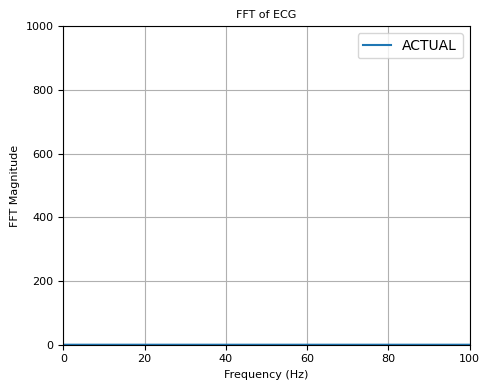

Top Peak Frequencies:


In [132]:
import numpy as np
from numpy.fft import fft, ifft
from scipy.signal import find_peaks
# FFT computation for STN
sr = 1000
#filtered_ecg_reshaped= ecg_data_reshaped
N_actual = len(ecg_cleaned_neurokit)
ecg_signal = ecg_cleaned_neurokit
freq_actual = np.fft.fftfreq(N_actual, d=1/sr)
fft_output_actual = np.fft.fft(ecg_signal) #Taking fft of the signal, not the reshaped data

# Keep only the positive half of frequencies
N_half = N_actual // 2
freq_actual = freq_actual[:N_half]
fft_magnitude = np.abs(fft_output_actual)[:N_half] #Taking the absolute value for magnitudes

plt.figure(figsize=(5, 4))
plt.plot(freq_actual, fft_magnitude, label='ACTUAL') #Plotting the frequency spectrum
plt.xlim(0, 100)
plt.ylim(0, 1000)
plt.title('FFT of ECG', fontsize=8)
plt.xlabel('Frequency (Hz)', fontsize=8)
plt.ylabel('FFT Magnitude', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.legend()
plt.tight_layout()

# Find the dominant frequency in the positive half
dominant_freq_index = np.argmax(fft_magnitude)
dominant_frequency = freq_actual[dominant_freq_index]
print(f"Dominant frequency: {dominant_frequency:.2f} Hz")

plt.show()


peak_indices, _ = find_peaks(fft_magnitude, height=10)  # Adjust height threshold as needed
peak_frequencies = freq_actual[peak_indices]
peak_magnitudes = fft_magnitude[peak_indices]

# Sort peaks by magnitude (highest first)
sorted_indices = np.argsort(peak_magnitudes)[::-1]
peak_frequencies = peak_frequencies[sorted_indices]
peak_magnitudes = peak_magnitudes[sorted_indices]

# 🎯 Print the top 5 peak frequencies
print("Top Peak Frequencies:")
for i in range(min(5, len(peak_frequencies))):
    print(f"Peak {i+1}: {peak_frequencies[i]:.2f} Hz, Magnitude: {peak_magnitudes[i]:.2f}")

--- Using device: cpu ---

--- Starting Training ---
Epoch 500, Train=0.017854, Val=0.002499
Epoch 1000, Train=0.011386, Val=0.001767
Epoch 1500, Train=0.005831, Val=0.005588
Epoch 2000, Train=0.001492, Val=0.015086
Epoch 2500, Train=0.000329, Val=0.023037
Epoch 3000, Train=0.000105, Val=0.027748
Epoch 3500, Train=0.000048, Val=0.030739
Epoch 4000, Train=0.000035, Val=0.034056
Epoch 4500, Train=0.000021, Val=0.034131
Epoch 5000, Train=0.000016, Val=0.034148
Epoch 5500, Train=0.000012, Val=0.034628
Epoch 6000, Train=0.000010, Val=0.034814
Epoch 6500, Train=0.000009, Val=0.035084
Epoch 7000, Train=0.000009, Val=0.035147
Epoch 7500, Train=0.000008, Val=0.035157
Epoch 8000, Train=0.000008, Val=0.034916
--- Training Finished ---



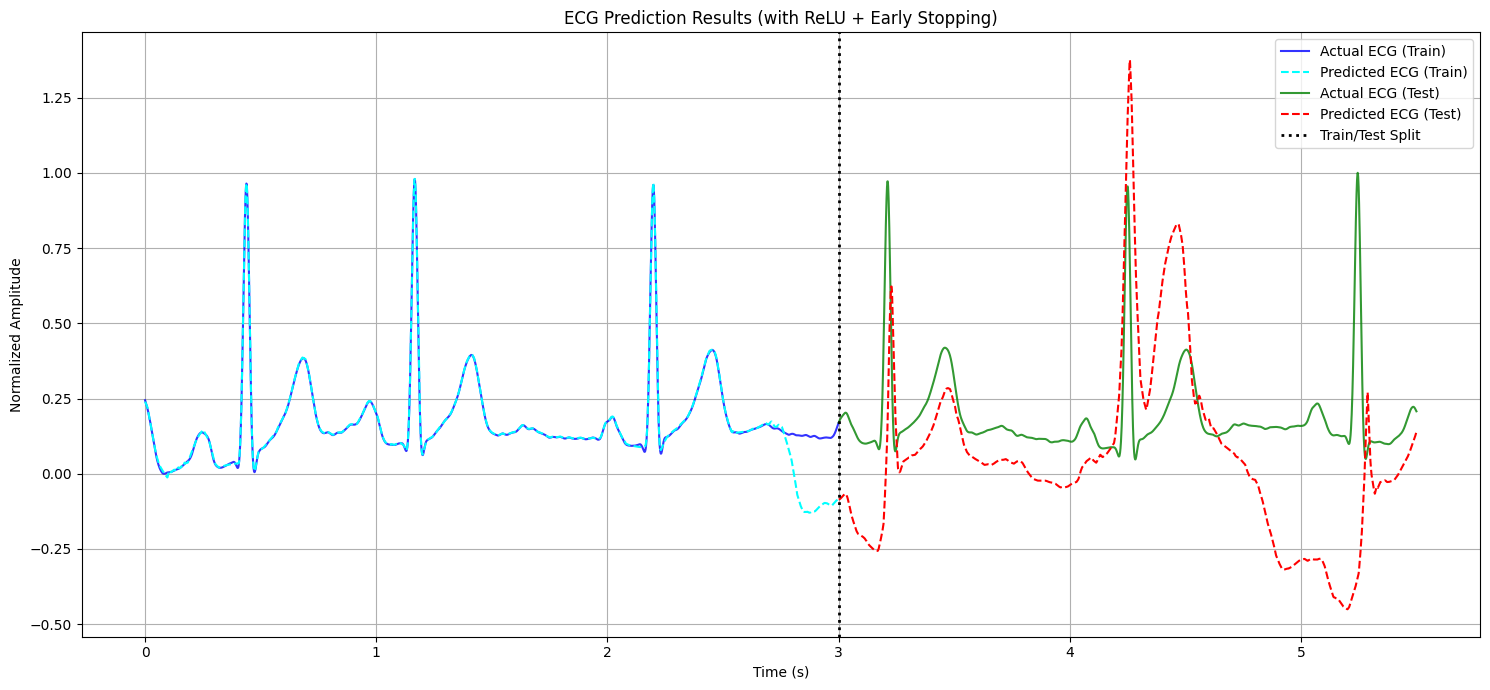

In [141]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Oscillator Simulation ---
def simulate_coupled_oscillators(T=5.5, dt=0.001, alpha=1.0, omega1=3, omega2=3.1,
                                 A_init=0.0001, theta_init=np.pi, n=1.0):
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2/(r1+1e-9)*np.sin(theta12 + n*(phi2 - phi1))
        dphi2 = omega2 + A21 * r1/(r2+1e-9)*np.sin(theta21 + n*(phi1 - phi2))
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),R1*np.sin(Phi1),
                     R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

# --- Heart Model (ReLU + Dropout) ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            #nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Main Execution ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # Assume you already have `normalized_ecg_basecorrect`
    ecg_processed = normalized_ecg_basecorrect.copy()

    # Setup
    train_duration = 3
    total_duration = 5.5
    fs = 1000
    t_full = np.arange(0, total_duration, 1/fs)
    train_samples = int(train_duration * fs)

    # Split ECG
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:].copy()

    # --- FIX 1: Simulate ONCE for full duration ---
    sim_osc_input_full_np = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_input_train = torch.tensor(sim_osc_input_full_np[:train_samples],
                                       dtype=torch.float32).to(device)
    sim_osc_input_full = torch.tensor(sim_osc_input_full_np,
                                      dtype=torch.float32).to(device)

    # Training targets
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)

    # Validation split (10% of training samples)
    val_frac = 0.1
    val_start = int(train_samples * (1 - val_frac))
    X_train = sim_osc_input_train[:val_start]
    y_train = ecg_target_train[:val_start]
    X_val = sim_osc_input_train[val_start:]
    y_val = ecg_target_train[val_start:]

    # Model, optimizer, loss
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-4, weight_decay=1e-6)
    criterion = nn.MSELoss()

    # --- FIX 2: Early stopping ---
    #best_val = float("inf")
    #patience, wait = 500, 0
    #best_state = None
    num_epochs =8000

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        heart_model.train()
        pred = heart_model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        heart_model.eval()
        with torch.no_grad():
            val_pred = heart_model(X_val)
            val_loss = criterion(val_pred, y_val)

        #if val_loss.item() < best_val:
         #   best_val = val_loss.item()
          #  best_state = heart_model.state_dict()
          #  wait = 0
        #else:
         #   wait += 1

        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Train={loss.item():.6f}, Val={val_loss.item():.6f}")

       # if wait > patience:
        #    print("Early stopping triggered.")
        #    break

    # Restore best weights
   # if best_state:
    #    heart_model.load_state_dict(best_state)
    print("--- Training Finished ---\n")

    # --- Prediction on full signal ---
    heart_model.eval()
    with torch.no_grad():
        predicted_ecg_full = heart_model(sim_osc_input_full).cpu().numpy().flatten()

    pred_ecg_train = predicted_ecg_full[:train_samples]
    pred_ecg_test = predicted_ecg_full[train_samples:]

    # --- Plot ---
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:]

    plt.figure(figsize=(15, 7))
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='green', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='red', linestyle='--')
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.title('ECG Prediction Results (with ReLU + Early Stopping)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


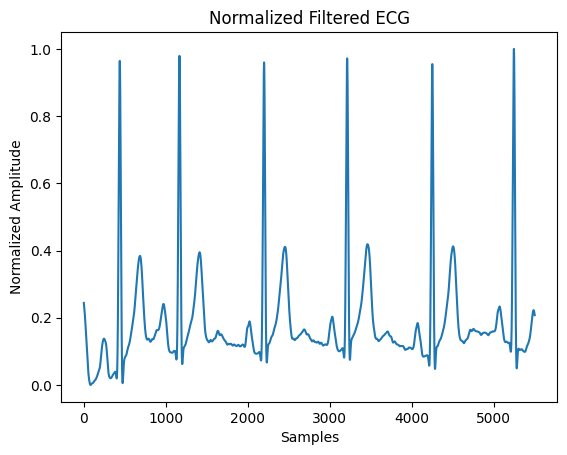

In [133]:

normalized_ecg_basecorrect = ((ecg_cleaned_neurokit - np.min(ecg_cleaned_neurokit)) / (np.max(ecg_cleaned_neurokit) - np.min(ecg_cleaned_neurokit))) ## use for modelling behaviour.
plt.figure()
plt.plot(normalized_ecg_basecorrect)
plt.title('Normalized Filtered ECG')
plt.xlabel('Samples')
plt.ylabel('Normalized Amplitude')
plt.show()

wHAT about base line correction by some other method  ?


In [28]:
from math import sqrt

class BWR:
    def __init__(self):
        # Daubechies 4 Constants
        self.c0 = (1+sqrt(3))/(4*sqrt(2))
        self.c1 = (3+sqrt(3))/(4*sqrt(2))
        self.c2 = (3-sqrt(3))/(4*sqrt(2))
        self.c3 = (1-sqrt(3))/(4*sqrt(2))

    def conv(self, x, h):
        length = len(x) + len(h) - 1
        y = [0] * length

        for i in range(len(y)):
            for j in range(len(h)):
                if 0 <= i - j < len(x):
                    y[i] += h[j] * x[i - j]

        return y

    def db4_dec(self, x, level):
        lpk = [self.c0, self.c1, self.c2, self.c3]
        hpk = [self.c3, -self.c2, self.c1, -self.c0]

        result = [[]] * (level + 1)
        x_temp = x[:]
        for i in range(level):
            lp = self.conv(x_temp, lpk)
            hp = self.conv(x_temp, hpk)

            lp_ds = [lp[2 * j + 1] for j in range(len(lp) // 2)]
            hp_ds = [hp[2 * j + 1] for j in range(len(hp) // 2)]

            result[level - i] = hp_ds
            x_temp = lp_ds[:]

        result[0] = lp_ds
        return result

    def db4_rec(self, signals, level):
        lpk = [self.c3, self.c2, self.c1, self.c0]
        hpk = [-self.c0, self.c1, -self.c2, self.c3]

        cp_sig = signals[:]
        for _ in range(level):
            lp, hp = cp_sig[:2]
            length = 2 * min(len(lp), len(hp))

            lpu = [0] * (length + 1)
            hpu = [0] * (length + 1)
            index = 0
            for j in range(length + 1):
                if j % 2 != 0:
                    lpu[j] = lp[index]
                    hpu[j] = hp[index]
                    index += 1

            lpc = self.conv(lpu, lpk)
            hpc = self.conv(hpu, hpk)

            lpt = lpc[3:-3]
            hpt = hpc[3:-3]
            org = [lpt[j] + hpt[j] for j in range(len(lpt))]

            cp_sig = [org] + cp_sig[2:] if len(cp_sig) > 2 else [org]

        return cp_sig[0]

    def calc_energy(self, x):
        return sum(i * i for i in x)

    def remove_baseline_wander(self, raw):
        en0 = en1 = en2 = 0
        n=0
        curlp = raw[:]
        num_dec = 0
        last_lp = []

        while True:
            print(f'Iteration {num_dec + 1}, Length: {len(curlp)}')
            lp, hp = self.db4_dec(curlp, 1)
            en0, en1, en2 = en1, en2, self.calc_energy(hp)
            print(f'Energy: {en2}')

            if en0 > en1 and en1 < en2:
                last_lp = curlp
                break

            curlp = lp[:]
            num_dec += 1

        base = last_lp[:]
        for _ in range(num_dec):
            base = self.db4_rec([base, [0] * len(base)], 1)

        ecg_out = [raw[i] - base[i] for i in range(len(raw))]
        return base, ecg_out

Iteration 1, Length: 4500
Energy: 4.49156178786746e-08
Iteration 2, Length: 2251
Energy: 1.943408958145132e-07
Iteration 3, Length: 1127
Energy: 1.391260462685869e-06
Iteration 4, Length: 565
Energy: 1.0438968253933527e-05
Iteration 5, Length: 284
Energy: 3.4473110566356675e-05
Iteration 6, Length: 143
Energy: 2.9952627883076414e-05
Iteration 7, Length: 73
Energy: 3.134737123276685e-05


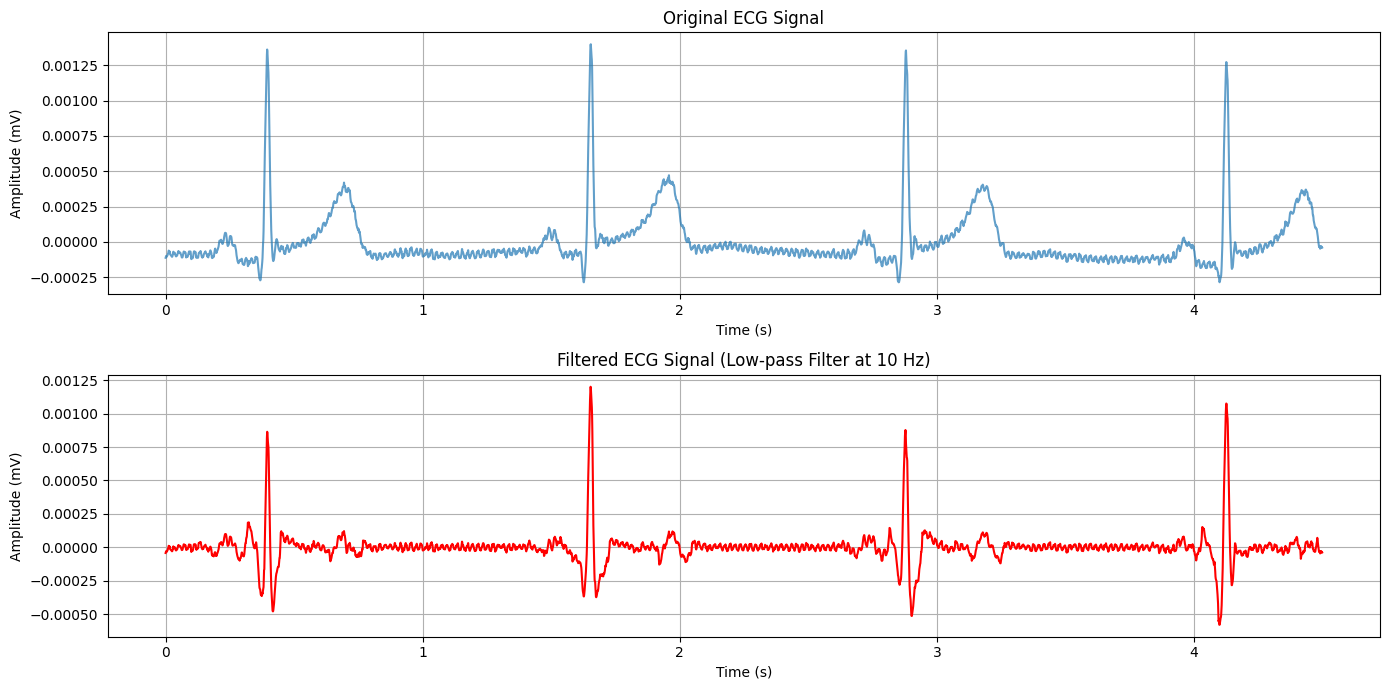

/tmp/ipython-input-1535216403.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=8, loc='upper right')


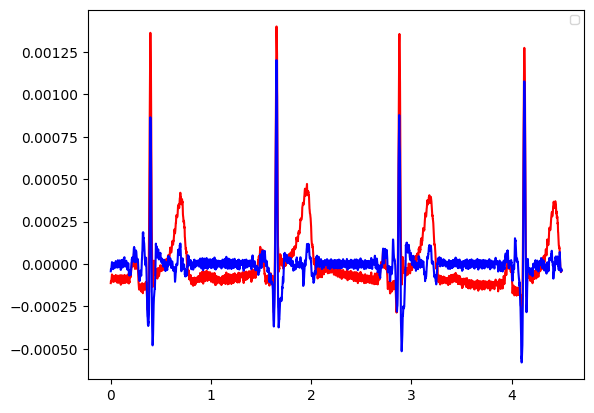

In [30]:
bwr_instance = BWR()  # Create an instance of the BWR class
(baseline, ecg_out) = bwr_instance.remove_baseline_wander()  # Call the method on the instance
 #plotting and check the difference..

plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(time_axis,ecg_data, label="Original ECG Signal", alpha=0.7)
plt.title("Original ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time_axis,ecg_out, label="Filtered ECG Signal", color='red')
plt.title("Filtered ECG Signal (Low-pass Filter at 10 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid()

plt.tight_layout()
plt.show()

plt.plot(time_axis,ecg_data, color='red') # Plot detrended signal
plt.plot(time_axis,ecg_out, color='blue')
plt.legend(fontsize=8, loc='upper right')